# 10v4b_01 — Mode-A ranking freeze

This notebook consumes **settled evidence only**. It refuses to run unless
`outputs/v4b/cache_settlement.json` says `ACCEPT_EXISTING` or `REBUILT_AND_VALIDATED`, and the
evidence files still hash to the recorded fingerprint. Normal execution never rebuilds QCR,
never reloads the raw spectra (apart from about 40 spectra for the example panels), and never
re-runs reference selection.

**Execution order enforces "DEV selects, HOST confirms" (spec §54).** The recommended section
list is reordered so that every DEV-phase output, including the selected model and the tuned
alphas, is persisted and locked **before** any HOST metric is computed:

| phase | sections |
|---|---|
| setup | 0 preconditions + waivers + pre-registration · 1 load · 2 query accounting · 3 feature sanity / popularity audit · 4 mass calibration (DEV-safe data) |
| **DEV only** | 5 B1/B1L/B2a/B2b · 6 B3a/B3b · 7 B4/B5 (alpha on DEV) · 8–12 V1, V2, V3, V4, V3-RD · 13 1k/3k/10k scaling · 14 DEV k-stress · 15 DEV connectivity bootstrap · **16 pre-registered selection → lock** |
| **HOST confirmation** | 17 HOST baselines + models · 18 HOST k=1/3/5 stress · 19 HOST connectivity bootstrap · 20 pool / reference / other stratification · 21 near_dup_strict sensitivity · 22 near-miss analysis + panels · 23 freeze table · 24 Mode-A freeze decision |

Any number quoted in this markdown is **HISTORICAL REFERENCE** (v4a/v4a.1), for example V0 on
mirror_aware ≈ 0.713, and V0 k=1/3/5 ≈ 0.620/0.684/0.714. All v4b numbers exist only in cell outputs and in `outputs/v4b/`.

In [3]:
import sys, json, time, gc
from pathlib import Path

NOTEBOOK_START = time.time()
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from casmi.paths import get_project_paths
from casmi.io.parquet import load_columns, load_rows_by_offset
from casmi.qcr.context import HOST_INGEST_LIB, SEED, v4b_paths
from casmi.qcr.settlement import load_settlement_or_refuse, offset_of
from casmi.qcr.aggregate import (
    SPECTRAL_FEATURE_COLS, TOP3_COLS, aggregate_deterministic, aggregate_reference_dropout, assert_no_top3_missingness_leak,
    eligible_reference_counts, nan_fraction_table, nan_pattern_by_ref_count, top3_sanity_table,
)
from casmi.ranking.rank_eval import per_query_metrics, query_accounting, rank_by_keys, summarize
from casmi.ranking.baselines import ALPHA_GRID, BASELINE_LABELS, fit_standardizer, run_all_baselines, select_alpha_dev
from casmi.ranking.mass_likelihood import MassLikelihoodModel, signed_truth_ppm
from casmi.ranking.lambdamart import (
    BASE_FEATURES, LGBM_PARAMS, MASS_LIK_FEATURES, connectivity_disjointness, fit_fold_models, predict_by_fold, save_fold_models,
)
from casmi.ranking.selection import (
    CANDIDATE_MODELS, HELD_OUT_VALIDITY, PREREGISTERED_RULE, SIMPLICITY_RANK, DevSelectionLock, lock_dev_selection,
    require_dev_selection_lock, select_from_dev_only, write_preregistration,
)
from casmi.ranking.training_sets import v2_filter, v3_filter
from casmi.ranking.near_miss import (
    build_near_miss_table, candidate_tier_flags, near_miss_category_summary, plot_example_panel, select_panel_examples,
)
from casmi.validation.cluster_bootstrap import cluster_bootstrap_mean, paired_comparison_row
from casmi.validation.decision_log import log_decision
from casmi.validation.baseline_registry import register_baseline
from casmi.validation.v4b_governance import mode_a_freeze_conditions, write_waivers

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 220)

PRIMARY, SENS = 'mirror_aware', 'near_dup_strict'
KEY = 'candidate_connectivity_key'
N_BOOT = 2000
K_STRESS = (1, 3, 5)
DROPOUT_CFG = {'k_choices': [1, 3, 5], 'k_probs': None, 'seed': SEED, 'n_replicas': 1, 'distribution': 'uniform over {1,3,5}'}
SCALE_STRATEGY = 'test_like'
LOW_N = 20
BASELINE_FILE = {'B1': 'B1_mass', 'B1L': 'B1L_mass_likelihood', 'B2a': 'B2a_availability', 'B2b': 'B2b_popularity',
                 'B3a': 'B3a_peak_random_ties', 'B3b': 'B3b_peak_mass_tie', 'B4': 'B4_peak_massfusion', 'B5': 'B5_modcos_massfusion'}
TRANSPARENT_PRODUCTION_BASELINES = ('B1', 'B1L', 'B3a', 'B3b', 'B4', 'B5')   # B2a/B2b are audits, never "best baseline"

paths = get_project_paths()
vp = v4b_paths(paths)
OUT = vp.out
D = {n: vp.subdir(n) for n in ('baselines', 'models', 'metrics', 'bootstrap', 'stress_tests', 'near_misses', 'figures')}
PREREG_PATH, LOCK_PATH = OUT / 'preregistration.json', OUT / 'dev_selection_lock.json'
DECISION_LOG_PATH = paths.outputs / 'decision_log.jsonl'
RESULTS = {'dev': {}, 'host': {}}


def save_json(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2, default=str), encoding='utf-8')

## 0. Preconditions, waivers, pre-registration

The pre-registered rule, the alpha grid, the LightGBM parameters and the dropout configuration
are written and hashed **before any metric exists**. `write_preregistration` refuses to change
a rule that has already been written.

In [5]:
settlement = load_settlement_or_refuse(vp.settlement_json)   # raises unless ACCEPT_EXISTING / REBUILT_AND_VALIDATED
ARTS = settlement['evidence_artifacts']
print('cache decision:', settlement['decision'], '| evidence fingerprint:', settlement['evidence_fingerprint'])
print('waivers ->', write_waivers(OUT))
prereg = write_preregistration(PREREG_PATH, extra={
    'alpha_grid': list(ALPHA_GRID), 'lgbm_params': LGBM_PARAMS, 'base_features': BASE_FEATURES, 'mass_features': MASS_LIK_FEATURES,
    'dropout_config': DROPOUT_CFG, 'scale_strategy': SCALE_STRATEGY, 'k_stress': list(K_STRESS), 'n_boot': N_BOOT,
    'primary_protocol': PRIMARY, 'sensitivity_protocol': SENS})
print('pre-registration sha256:', prereg['rule_sha256'])
print(json.dumps(PREREGISTERED_RULE, indent=1)[:1500])
log_decision(decision='v4b 10v4b_01 pre-registered Mode-A selection rule written before any metric',
             evidence_used=f"rule sha256 {prereg['rule_sha256']}", host_visible=False, category='pre_registered_choice', log_path=DECISION_LOG_PATH)

cache decision: REBUILT_AND_VALIDATED | evidence fingerprint: 14cc3ca0bf9be807b84c9e1e
waivers -> C:\Users\myben\OneDrive\Documents\Enveda\outputs\v4b\waivers.json
pre-registration sha256: 5de3c7ffbb926744ae1a6d7ce775408bcd261374f8905a4184201df91c17713e
{
 "rule_id": "v4b-modeA-selection-1",
 "primary_metric": "DEV connectivity-safe OOF MRR@25 (all DEV queries in the denominator; zero-candidate queries RR=0)",
 "candidate_models": [
  "V1",
  "V2",
  "V3",
  "V4",
  "V3_RD",
  "V1_1k",
  "V1_3k",
  "V1_10k"
 ],
 "near_tie_margin": 0.005,
 "near_tie_preference_order": [
  "higher DEV OOF k=1 stress MRR@25",
  "higher held-out validity (source+structure > source > protocol-matched)",
  "simpler model (SIMPLICITY_RANK ascending)",
  "model_id ascending (final deterministic tie-break)"
 ],
 "held_out_validity": {
  "V1": 0,
  "V2": 1,
  "V3": 2,
  "V4": 2,
  "V3_RD": 2,
  "V1_1k": 0,
  "V1_3k": 0,
  "V1_10k": 0
 },
 "simplicity_rank": {
  "V1": 0,
  "V1_1k": 0,
  "V2": 1,
  "V3": 2,
  "V1_

{'timestamp': '2026-09-24T21:38:16.465271+00:00',
 'decision': 'v4b 10v4b_01 pre-registered Mode-A selection rule written before any metric',
 'evidence_used': 'rule sha256 5de3c7ffbb926744ae1a6d7ce775408bcd261374f8905a4184201df91c17713e',
 'host_visible': False,
 'category': 'pre_registered_choice'}

## 1. Load the frozen DEV/HOST evidence (persisted artifacts only)

In [6]:
QCR_COLS = ['query_id', 'candidate_key', 'is_true', 'ref_spectrum_id', 'compat_rank', 'tier', 'cosine', 'modified_cosine',
            'peak_overlap_frac', 'neutral_loss_cosine'] + [f'{a}_{p}' for a in ('eligible', 'accepted') for p in (PRIMARY, SENS)]
dev_q = pd.read_parquet(paths.interim / 'spectral_ranking' / 'dev_ranking_queries.parquet')
host_q = pd.read_parquet(vp.host_processed / 'host_holdout_spectra.parquet').assign(source=lambda d: d['ingest_lib'])
DEV_IDS, HOST_IDS = dev_q['query_id'].tolist(), host_q['query_id'].tolist()
QMETA = ['query_id', 'fold', 'true_connectivity_key', 'source', 'instrument_type', 'adduct', 'neutral_mass']
dev_meta, host_meta = dev_q[QMETA], host_q[QMETA]
CLUSTER_DEV = dev_q.set_index('query_id')['true_connectivity_key'].to_dict()
CLUSTER_HOST = host_q.set_index('query_id')['true_connectivity_key'].to_dict()


def with_meta(feats, meta):
    return feats.drop(columns=[c for c in ('fold',) if c in feats.columns]).merge(meta, on='query_id', how='left', validate='many_to_one')


dev_f = {p: with_meta(pd.read_parquet(ARTS[f'dev_features_{p}']), dev_meta) for p in (PRIMARY, SENS)}
host_f = {p: with_meta(pd.read_parquet(ARTS[f'host_features_{p}']), host_meta) for p in (PRIMARY, SENS)}
dev_qcr = pd.read_parquet(ARTS['dev_qcr'], columns=QCR_COLS)
host_qcr = pd.read_parquet(ARTS['host_qcr'], columns=QCR_COLS)
dev_pairs = pd.read_parquet(ARTS['dev_qcr_pairs'], columns=['query_id', 'candidate_key', 'exhausted'])
host_pairs = pd.read_parquet(ARTS['host_qcr_pairs'], columns=['query_id', 'candidate_key', 'exhausted'])
POOL_COLS = ['query_id', KEY, 'abs_mass_error_ppm', 'is_true_candidate']
dev_pool, host_pool = dev_f[PRIMARY][POOL_COLS], host_f[PRIMARY][POOL_COLS]
for name, df in [('dev', dev_f[PRIMARY]), ('host', host_f[PRIMARY])]:
    assert df['fold'].notna().all(), f'{name}: every feature row needs a connectivity fold'
print(f'DEV features: {len(dev_f[PRIMARY]):,} rows | HOST features: {len(host_f[PRIMARY]):,} rows | DEV QCR {len(dev_qcr):,} | HOST QCR {len(host_qcr):,}')

DEV features: 248,027 rows | HOST features: 126,573 rows | DEV QCR 1,473,184 | HOST QCR 549,625


## 2. Query accounting (every DEV query accounted for)

Training uses only queries with candidates, so no LightGBM group is ever empty. Every DEV/HOST
metric in this notebook uses **all** intended queries as the denominator. A zero-candidate
query counts as RR = 0 and Hit@k = 0.

In [7]:
acct = {'dev': query_accounting(DEV_IDS, dev_f[PRIMARY]), 'host': query_accounting(HOST_IDS, host_f[PRIMARY])}
display(pd.DataFrame(acct).T)
RESULTS['query_accounting'] = acct
RESULTS['n_dev_queries_total'] = acct['dev']['n_queries_total']
RESULTS['n_dev_queries_with_candidates'] = acct['dev']['n_queries_with_candidates']
RESULTS['n_dev_queries_without_candidates'] = acct['dev']['n_queries_without_candidates']
assert acct['dev']['n_feature_rows_outside_query_list'] == 0 and acct['host']['n_feature_rows_outside_query_list'] == 0
save_json(acct, D['metrics'] / 'query_accounting.json')

,n_queries_total,n_queries_with_candidates,n_queries_without_candidates,n_queries_truth_in_pool,n_queries_truth_absent_from_nonempty_pool,n_feature_rows_outside_query_list
dev,1000,996,4,980,16,0
host,1184,1184,0,1184,0,0


## 3. Feature sanity: `*_top3_mean`, missingness, reference popularity (audit only)

Contract: `top3_mean` is the mean of the available selected references (1 → that value,
2 → the mean of both, ≥ 3 → the mean of the top 3). A NaN appears only when there are no
references. If a persisted table violates this, **only** the candidate-level tables are
rebuilt from QCR (`aggregate_deterministic`). Similarities are never rebuilt.

In [8]:
TOP3_REBUILT = {}
for name, feats, qcr, meta in [('dev', dev_f, dev_qcr, dev_meta), ('host', host_f, host_qcr, host_meta)]:
    for p in (PRIMARY, SENS):
        try:
            assert_no_top3_missingness_leak(feats[p])
            TOP3_REBUILT[f'{name}_{p}'] = False
        except AssertionError as e:
            print(f'{name}/{p}: {e} -> rebuilding candidate-level features from QCR (no similarity recomputation)')
            feats[p] = with_meta(aggregate_deterministic(qcr, feats[p][POOL_COLS], p), meta)
            assert_no_top3_missingness_leak(feats[p])
            TOP3_REBUILT[f'{name}_{p}'] = True
print('top3 tables rebuilt from QCR:', TOP3_REBUILT)
display(top3_sanity_table(dev_f[PRIMARY]).assign(dataset='dev'))
display(top3_sanity_table(host_f[PRIMARY]).assign(dataset='host'))
print('joint NaN pattern of the 4 top3 features vs reference-count bin (DEV, mirror_aware):')
display(nan_pattern_by_ref_count(dev_f[PRIMARY], TOP3_COLS))
nan_tab = pd.concat([nan_fraction_table(dev_f[p], SPECTRAL_FEATURE_COLS, f'dev_{p}') for p in (PRIMARY, SENS)] +
                    [nan_fraction_table(host_f[p], SPECTRAL_FEATURE_COLS, f'host_{p}') for p in (PRIMARY, SENS)], ignore_index=True)
nan_tab.to_parquet(D['metrics'] / 'feature_nan_fractions.parquet', index=False)

# reference popularity: AUDIT columns (never main-model features -- enforced by lambdamart.FORBIDDEN_MODEL_FEATURES)
for name, feats, qcr, pairs in [('dev', dev_f, dev_qcr, dev_pairs), ('host', host_f, host_qcr, host_pairs)]:
    for p in (PRIMARY, SENS):
        cnt = eligible_reference_counts(qcr, pairs, feats[p][POOL_COLS], protocol=p)
        feats[p] = feats[p].merge(cnt, on=['query_id', KEY], how='left', validate='one_to_one')
pop = dev_f[PRIMARY].groupby('is_true_candidate')['popularity_level'].value_counts(normalize=True).unstack(fill_value=0)
print('DEV popularity_level distribution (truth vs decoy) -- the signal B2b audits:')
display(pop)
RESULTS['top3_contract_holds'] = bool(all(assert_no_top3_missingness_leak(f[p]) for f in (dev_f, host_f) for p in (PRIMARY, SENS)))
RESULTS['top3_tables_rebuilt_from_qcr'] = TOP3_REBUILT

top3 tables rebuilt from QCR: {'dev_mirror_aware': False, 'dev_near_dup_strict': False, 'host_mirror_aware': False, 'host_near_dup_strict': False}


,ref_count_bin,n_rows,nan_frac_cosine_max,nan_frac_cosine_top3_mean,nan_frac_modified_cosine_max,nan_frac_modified_cosine_top3_mean,nan_frac_peak_overlap_frac_max,nan_frac_peak_overlap_frac_top3_mean,nan_frac_neutral_loss_cosine_max,nan_frac_neutral_loss_cosine_top3_mean,max_absdiff_top3_vs_max_cosine,max_absdiff_top3_vs_max_modified_cosine,max_absdiff_top3_vs_max_peak_overlap_frac,max_absdiff_top3_vs_max_neutral_loss_cosine,dataset
0,0,143165,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,dev
1,1,5302,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,dev
2,2,4941,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,dev
3,>=3,94619,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,dev


,ref_count_bin,n_rows,nan_frac_cosine_max,nan_frac_cosine_top3_mean,nan_frac_modified_cosine_max,nan_frac_modified_cosine_top3_mean,nan_frac_peak_overlap_frac_max,nan_frac_peak_overlap_frac_top3_mean,nan_frac_neutral_loss_cosine_max,nan_frac_neutral_loss_cosine_top3_mean,max_absdiff_top3_vs_max_cosine,max_absdiff_top3_vs_max_modified_cosine,max_absdiff_top3_vs_max_peak_overlap_frac,max_absdiff_top3_vs_max_neutral_loss_cosine,dataset
0,1,4450,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,host
1,2,6068,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,host
2,>=3,116055,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,host


joint NaN pattern of the 4 top3 features vs reference-count bin (DEV, mirror_aware):


col_0,0,1,2,>=3
row_0,,,,
....,0,5302,4941,94619
NNNN,143165,0,0,0


c:\Users\myben\OneDrive\Documents\Enveda\src\casmi\qcr\aggregate.py:142: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["exhausted"] = out["exhausted"].fillna(True).astype(bool)
c:\Users\myben\OneDrive\Documents\Enveda\src\casmi\qcr\aggregate.py:142: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["exhausted"] = out["exhausted"].fillna(True).astype(bool)


DEV popularity_level distribution (truth vs decoy) -- the signal B2b audits:


popularity_level,0,1,2,3,4,5
is_true_candidate,,,,,,
False,0.576995,0.021364,0.019940,0.041377,0.056872,0.283452
True,0.632653,0.024490,0.015306,0.011224,0.009184,0.307143


## 4. Mass calibration: `log P(|mass error| | instrument, adduct)` from DEV-safe data only

The fitting data is notebook 03's 60k `dev_queries` spectrum sample, **minus** every HOST-source
spectrum and **minus** the 1,000 DEV evaluation queries. The truth ppm error uses the same
definition the candidate generator uses. The model backs off from instrument + adduct to
instrument, then adduct, then global, with at least 200 samples per level.

mass model: {'n_rows_fit': 57718, 'n_groups': {'instrument_adduct': 30, 'instrument': 14, 'adduct': 11, 'global': 1}, 'tol_ppm': 50.0, 'eps': 0.02, 'min_n': 200, 'min_scale_ppm': 0.1}
back-off level used (DEV rows): {'instrument_adduct': 239683, 'instrument': 7017, 'adduct': 1327}


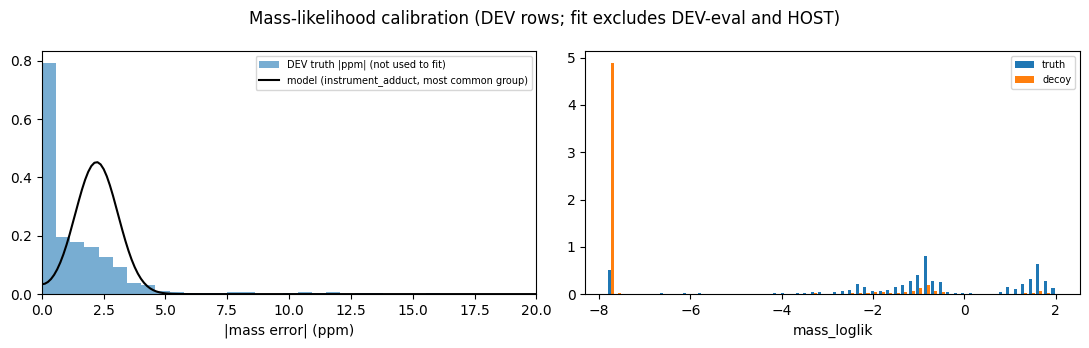

In [9]:
with open(paths.processed / 'candidate_generation' / 'candidate_generation_contract.json') as f:
    SELECTED_PPM = json.load(f)['molecule_policy']['tolerance_ppm']
dq60 = pd.read_parquet(paths.interim / 'candidate_generation' / 'dev_queries.parquet')
fit_df = dq60[(dq60['source'] != HOST_INGEST_LIB) & ~dq60['query_id'].isin(set(DEV_IDS))].copy()
fit_df['truth_ppm'] = signed_truth_ppm(fit_df['neutral_mass'], fit_df['exact_mass_true'])
mass_model = MassLikelihoodModel(tol_ppm=float(SELECTED_PPM), eps=0.02, min_n=200).fit(fit_df, forbidden_sources=(HOST_INGEST_LIB,))
print('mass model:', mass_model.fit_info)
save_json(mass_model.to_dict(), D['metrics'] / 'mass_likelihood_model.json')
for feats in (dev_f, host_f):
    for p in (PRIMARY, SENS):
        ll, lvl = mass_model.loglik(feats[p])
        feats[p] = feats[p].assign(mass_loglik=ll, mass_loglik_level=lvl)
print('back-off level used (DEV rows):', dev_f[PRIMARY]['mass_loglik_level'].value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
truth = dev_f[PRIMARY][dev_f[PRIMARY]['is_true_candidate']]
axes[0].hist(truth['abs_mass_error_ppm'], bins=80, density=True, alpha=0.6, label='DEV truth |ppm| (not used to fit)')
grid = np.linspace(0, float(SELECTED_PPM), 400)
p0, lvl0 = mass_model.resolve(*truth[['instrument_type', 'adduct']].astype(str).mode().iloc[0])
axes[0].plot(grid, np.exp(mass_model._folded_logpdf(grid, p0['mu'], p0['s'])), 'k-', label=f'model ({lvl0}, most common group)')
axes[0].set_xlabel('|mass error| (ppm)'); axes[0].legend(fontsize=7); axes[0].set_xlim(0, min(20, float(SELECTED_PPM)))
d = dev_f[PRIMARY]
axes[1].hist([d.loc[d['is_true_candidate'], 'mass_loglik'], d.loc[~d['is_true_candidate'], 'mass_loglik']], bins=60, density=True, label=['truth', 'decoy'])
axes[1].set_xlabel('mass_loglik'); axes[1].legend(fontsize=7)
fig.suptitle('Mass-likelihood calibration (DEV rows; fit excludes DEV-eval and HOST)'); fig.tight_layout()
fig.savefig(D['figures'] / 'mass_calibration.png', dpi=130); plt.show()

# DEV PHASE: no HOST metric is computed until section 16 locks the selection

## 5–7. Transparent baselines on DEV (B1, B1L, B2a, B2b, B3a, B3b, B4, B5)

* **B2a** (availability) and **B2b** (popularity) are **audits**. **B2b — POPULARITY AUDIT ONLY,
  NOT A PRODUCTION FEATURE.** Its ordering is censoring-safe:
  `>=5 (saturated or exact >=5) > 4 > 3 > 2 > 1 > 0`, then mass.
* **B3a** uses peak overlap alone and gives the expected metric under uniformly random order
  inside exact score ties. It uses no mass at all.
* **B3b is not a pure spectrum-only ranking**, because mass is used as a deterministic secondary
  key.
* **B4/B5** alpha is chosen on DEV only, from the predefined grid, with ties going to the
  smaller alpha. The z-standardizer is fitted on DEV rows. A nested fold-held-out estimate of
  the tuning procedure is also reported.

In [10]:
DEV_FOLD = dev_q.set_index('query_id')['fold'].to_dict()
DEVP = dev_f[PRIMARY]
STD = fit_standardizer(DEVP, ['peak_overlap_frac_max', 'modified_cosine_max', 'mass_loglik'])
ALPHAS, alpha_tables = {}, {}
for bid, col in (('B4', 'peak_overlap_frac_max'), ('B5', 'modified_cosine_max')):
    ALPHAS[bid], grid_t, cv_t = select_alpha_dev(DEVP, DEV_IDS, DEV_FOLD, col, STD, alpha_grid=ALPHA_GRID)
    alpha_tables[bid] = (grid_t, cv_t)
    print(f'{bid}: alpha={ALPHAS[bid]}  (nested DEV estimate of the tuning procedure: '
          f"{(cv_t['heldout_mrr_at_25'] * cv_t['n_heldout_queries']).sum() / cv_t['n_heldout_queries'].sum():.4f})")
    display(grid_t.T)
    grid_t.to_parquet(D['baselines'] / f'{BASELINE_FILE[bid]}.dev_alpha_grid.parquet', index=False)
    cv_t.to_parquet(D['baselines'] / f'{BASELINE_FILE[bid]}.dev_alpha_nested_cv.parquet', index=False)

dev_pq = run_all_baselines(DEVP, DEV_IDS, ALPHAS, STD)
for bid, pq in dev_pq.items():
    pq.to_parquet(D['baselines'] / f'{BASELINE_FILE[bid]}.dev_per_query.parquet', index=False)
    RESULTS['dev'][bid] = summarize(pq)
dev_baseline_table = pd.DataFrame([{'model': b, 'label': BASELINE_LABELS[b], **RESULTS['dev'][b]} for b in dev_pq])
display(dev_baseline_table)
BEST_BASELINE = max(TRANSPARENT_PRODUCTION_BASELINES, key=lambda b: (RESULTS['dev'][b]['mrr_at_25'], -TRANSPARENT_PRODUCTION_BASELINES.index(b)))
print('best transparent (non-audit) baseline on DEV:', BEST_BASELINE)

B4: alpha=2.0  (nested DEV estimate of the tuning procedure: 0.3584)


,0,1,2,3,4,5,6
alpha,0.000000,0.050000,0.100000,0.200000,0.500000,1.000000,2.000000
dev_mrr_at_25,0.277021,0.278072,0.280871,0.290517,0.311757,0.343434,0.358405


B5: alpha=2.0  (nested DEV estimate of the tuning procedure: 0.3528)


,0,1,2,3,4,5,6
alpha,0.000000,0.050000,0.100000,0.200000,0.50000,1.000000,2.000000
dev_mrr_at_25,0.266557,0.287125,0.297269,0.308163,0.32247,0.333737,0.352796


,model,label,n_queries,n_with_candidates,mrr_at_25,hit_at_1,hit_at_5,hit_at_25
0,B1,B1 mass only,1000,996,0.289946,0.167000,0.432000,0.747000
1,B1L,B1L mass likelihood,1000,996,0.292846,0.169000,0.434000,0.744000
2,B2a,B2a availability + mass (AUDIT),1000,996,0.183120,0.113000,0.269000,0.433000
3,B2b,B2b -- POPULARITY AUDIT ONLY -- NOT A PRODUCTI...,1000,996,0.186090,0.119000,0.263000,0.414000
4,B3a,"B3a peak overlap, expected random ties (spectr...",1000,996,0.253872,0.211551,0.301562,0.403159
5,B3b,B3b peak overlap + mass tie-break (NOT pure sp...,1000,996,0.266536,0.221000,0.317000,0.430000
6,B4,B4 peak overlap + alpha*mass likelihood,1000,996,0.358405,0.266000,0.456000,0.716000
7,B5,B5 modified cosine + alpha*mass likelihood,1000,996,0.352796,0.263000,0.450000,0.705000


best transparent (non-audit) baseline on DEV: B4


## 8–12. Rankers V1, V2, V3, V4, V3-RD (DEV OOF only)

| model | training queries | features | notes |
|---|---|---|---|
| V1 | all DEV (protocol-matched, mirror_aware) | base 9 | first clean replacement of historical V0 |
| V2 | DEV minus HOST-source queries | base 9 | source held out |
| V3 | V2 minus every query whose truth is a HOST connectivity | base 9 | source + structure held out (primary clean generalization variant) |
| V4 | as V3 | base 9 + `mass_loglik` (keeps `abs_mass_error_ppm`) | |
| V3-RD | as V3 | base 9 | **training** features rebuilt from QCR with random reference dropout (k ~ uniform{1,3,5}, random refs from the eligible set); evaluation always uses deterministic features |

All variants share one set of LightGBM parameters (the historical V0 ones) and the seed, and
use one group per query. Fold model *f* is trained on training queries whose connectivity
fold ≠ *f* and scores DEV evaluation queries of fold *f*. The DEV evaluation set is the same
for every variant: all 1,000 DEV queries. HOST is scored later by the fold-matched model.

In [11]:
MODELS, DEV_PQ_MODELS, MODEL_FEATS, TRAIN_AUDIT, STATUS = {}, {}, {}, {}, {}
EVAL_IDS_BY_FOLD = dev_q.groupby('fold')['query_id'].apply(set).to_dict()
HOST_KEYS = set(host_q['true_connectivity_key'])


def score_frame(models, df, feats):
    s = predict_by_fold(models, df, feats)
    assert s.notna().all(), f'{int(s.isna().sum())} rows have no fold-matched model'
    return df.assign(score=s.to_numpy())


def per_query_from_scores(df, ids):
    # model-score ties (rare) resolve deterministically by mass, then key -- same for every model
    return per_query_metrics(rank_by_keys(df, [('score', False), ('abs_mass_error_ppm', True), (KEY, True)]), ids)


def train_variant(model_id, train_df, feats, group_col=None, extra_meta=None):
    tq = train_df[['query_id', 'fold', 'true_connectivity_key']].drop_duplicates('query_id')
    disj = connectivity_disjointness(tq, dev_q)
    assert (disj['n_overlap'] == 0).all(), f'{model_id}: connectivity leak between training and DEV-eval folds\n{disj}'
    models, audit = fit_fold_models(train_df, feats, fold_col='fold', folds=sorted(dev_q['fold'].unique()), params=LGBM_PARAMS,
                                    group_col=group_col, eval_query_ids_by_fold=EVAL_IDS_BY_FOLD)
    save_fold_models(models, D['models'] / model_id, feats, LGBM_PARAMS, tq['query_id'],
                     extra={'model_id': model_id, 'evidence_fingerprint': settlement['evidence_fingerprint'], **(extra_meta or {})})
    MODELS[model_id], MODEL_FEATS[model_id], TRAIN_AUDIT[model_id] = models, feats, audit
    pq = per_query_from_scores(score_frame(models, DEVP, feats), DEV_IDS)
    pq.to_parquet(D['models'] / model_id / 'dev_oof_per_query.parquet', index=False)
    DEV_PQ_MODELS[model_id] = pq
    RESULTS['dev'][model_id] = summarize(pq)
    STATUS[model_id] = 'OK'
    print(f"{model_id}: {tq['query_id'].nunique():,} training queries, {len(train_df):,} rows | DEV OOF MRR@25 = {RESULTS['dev'][model_id]['mrr_at_25']:.4f}")


train_ids = {
    'V1': set(dev_q['query_id']),
    'V2': set(v2_filter(dev_q, HOST_INGEST_LIB)['query_id']),
    'V3': set(v3_filter(dev_q, HOST_INGEST_LIB, HOST_KEYS)['query_id']),
}
print({k: len(v) for k, v in train_ids.items()}, '(training queries before dropping zero-candidate queries)')
train_variant('V1', DEVP, BASE_FEATURES)
train_variant('V2', DEVP[DEVP['query_id'].isin(train_ids['V2'])], BASE_FEATURES)
train_variant('V3', DEVP[DEVP['query_id'].isin(train_ids['V3'])], BASE_FEATURES)
train_variant('V4', DEVP[DEVP['query_id'].isin(train_ids['V3'])], MASS_LIK_FEATURES)

# V3-RD: TRAINING features with random reference dropout; evaluation features stay deterministic
v3_pool = dev_pool[dev_pool['query_id'].isin(train_ids['V3'])]
v3_qcr = dev_qcr[dev_qcr['query_id'].isin(train_ids['V3'])]
rd_parts, rd_logs = [], []
for r in range(DROPOUT_CFG['n_replicas']):
    feats_r, log_r = aggregate_reference_dropout(v3_qcr, v3_pool, PRIMARY, k_choices=DROPOUT_CFG['k_choices'],
                                                 k_probs=DROPOUT_CFG['k_probs'], seed=DROPOUT_CFG['seed'] + r)
    rd_parts.append(with_meta(feats_r, dev_meta).assign(group_id=lambda d, r=r: d['query_id'] + f'#rd{r}'))
    rd_logs.append(log_r.assign(replica=r))
rd_train = pd.concat(rd_parts, ignore_index=True)
assert_no_top3_missingness_leak(rd_train)
rd_log = pd.concat(rd_logs, ignore_index=True)
rd_log.to_parquet(D['models'] / 'V3_RD_dropout_draws.parquet', index=False)
print('dropout draw k distribution:', rd_log['dropout_k'].value_counts(normalize=True).sort_index().to_dict(),
      '| truth rows k distribution:', rd_log.merge(v3_pool.rename(columns={KEY: 'candidate_key'}), on=['query_id', 'candidate_key'])
      .groupby('is_true_candidate')['n_sampled'].mean().to_dict())
train_variant('V3_RD', rd_train, BASE_FEATURES, group_col='group_id' if DROPOUT_CFG['n_replicas'] > 1 else None,
              extra_meta={'dropout_config': DROPOUT_CFG})
MODELS['V1_1k'], MODEL_FEATS['V1_1k'], DEV_PQ_MODELS['V1_1k'] = MODELS['V1'], MODEL_FEATS['V1'], DEV_PQ_MODELS['V1']
RESULTS['dev']['V1_1k'], STATUS['V1_1k'] = RESULTS['dev']['V1'], 'OK'   # the 1k scale point IS V1 (identical training table)

{'V1': 1000, 'V2': 1000, 'V3': 973} (training queries before dropping zero-candidate queries)
V1: 996 training queries, 248,027 rows | DEV OOF MRR@25 = 0.4318
V2: 996 training queries, 248,027 rows | DEV OOF MRR@25 = 0.4318
V3: 970 training queries, 245,445 rows | DEV OOF MRR@25 = 0.4324
V4: 970 training queries, 245,445 rows | DEV OOF MRR@25 = 0.4349
dropout draw k distribution: {1: 0.33180587988158167, 3: 0.3344634534778063, 5: 0.333730666640612} | truth rows k distribution: {False: 2.729490761162574, True: 2.6497005988023954}
V3_RD: 970 training queries, 245,445 rows | DEV OOF MRR@25 = 0.4293


## 13. Training-scale experiment: 1k → 3k → 10k (V1-style; built offline)

The 3k/10k feature tables come from `scripts/v4b_build_scale_features.py` (chunked, resumable,
test-like sampling). Feature definitions, LightGBM parameters, fold strategy, seed and
objective are identical across the three sizes, with no retuning. The DEV evaluation set is
still the fixed DEV-1k OOF. The sets are nested and the folds are global connectivity folds,
so model *f* never trains on a fold-*f* evaluation query. If the offline build has not been
run, V1_3k and V1_10k are reported as **NOT_RUN** and are excluded from selection.

[test_like] no scale manifest at C:\Users\myben\OneDrive\Documents\Enveda\data\processed\v4b_scale\test_like\scale_manifest.json -> scale models NOT_RUN
[random] no scale manifest at C:\Users\myben\OneDrive\Documents\Enveda\data\processed\v4b_scale\random\scale_manifest.json -> scale models NOT_RUN
status: {'V1': 'OK', 'V2': 'OK', 'V3': 'OK', 'V4': 'OK', 'V3_RD': 'OK', 'V1_1k': 'OK', 'V1_3k': 'NOT_RUN', 'V1_10k': 'NOT_RUN'}


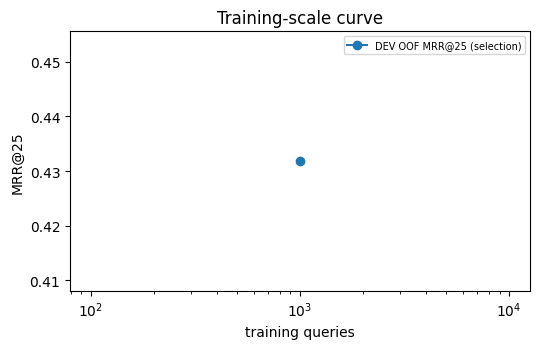

In [12]:
SCALE_TRAIN_COUNTS = {'V1_1k': len(train_ids['V1'])}
for strategy, tag in ((SCALE_STRATEGY, ''), ('random', '_random')):
    manifest_path = vp.scale_dir / strategy / 'scale_manifest.json'
    if not manifest_path.exists():
        print(f'[{strategy}] no scale manifest at {manifest_path} -> scale models NOT_RUN')
        continue
    manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
    assert manifest['evidence_fingerprint'] == settlement['evidence_fingerprint'], 'scale features were built on different evidence'
    assert manifest['protocol'] == PRIMARY
    for name in ('3k', '10k'):
        if name not in manifest['sets']:
            continue
        mid = f'V1_{name}{tag}'
        sf = pd.read_parquet(manifest['sets'][name]['path'])
        assert_no_top3_missingness_leak(sf)
        train_variant(mid, sf, BASE_FEATURES, extra_meta={'scale_set': name, 'strategy': strategy})
        SCALE_TRAIN_COUNTS[mid] = manifest['sets'][name]['n_queries_selected']
        del sf; gc.collect()
for mid in CANDIDATE_MODELS:
    STATUS.setdefault(mid, 'NOT_RUN')
print('status:', STATUS)


def scale_curve(host_results=None):
    pts = [(SCALE_TRAIN_COUNTS[m], m) for m in ('V1_1k', 'V1_3k', 'V1_10k') if STATUS.get(m) == 'OK']
    xs = [p[0] for p in pts]
    fig, ax = plt.subplots(figsize=(5.5, 3.6))
    ax.plot(xs, [RESULTS['dev'][m]['mrr_at_25'] for _, m in pts], 'o-', label='DEV OOF MRR@25 (selection)')
    if host_results:
        ax.plot(xs, [host_results[m]['mrr_at_25'] for _, m in pts], 's--', label='HOST MRR@25 (confirmation only)')
    rnd = [(SCALE_TRAIN_COUNTS[m], RESULTS['dev'][m]['mrr_at_25']) for m in ('V1_3k_random', 'V1_10k_random') if STATUS.get(m) == 'OK']
    if rnd:
        ax.plot([len(train_ids['V1'])] + [r[0] for r in rnd], [RESULTS['dev']['V1_1k']['mrr_at_25']] + [r[1] for r in rnd], 'x:', label='DEV OOF, random sampling (control)')
    ax.set_xscale('log'); ax.set_xlabel('training queries'); ax.set_ylabel('MRR@25'); ax.legend(fontsize=7); ax.set_title('Training-scale curve')
    fig.tight_layout()
    return fig


fig = scale_curve(); fig.savefig(D['figures'] / 'scale_curve_dev.png', dpi=130); plt.show()

## 14. DEV k = 1 / 3 / 5 reference stress (feeds the pre-registered tie-break)

DEV evaluation features are rebuilt from QCR using at most *k* accepted mirror-aware
references in compat-rank order. Truth and decoys get the same rule. Every trained model is
scored OOF.

In [13]:
def k_features(qcr, pool, meta, k):
    f = with_meta(aggregate_deterministic(qcr, pool, PRIMARY, k=k), meta)
    ll, _ = mass_model.loglik(f)
    return f.assign(mass_loglik=ll)


DEV_K = {k: k_features(dev_qcr, dev_pool, dev_meta, k) for k in K_STRESS}
dev_stress_rows = []
for mid in MODELS:
    for k in K_STRESS:
        pq = per_query_from_scores(score_frame(MODELS[mid], DEV_K[k], MODEL_FEATS[mid]), DEV_IDS)
        dev_stress_rows.append({'model': mid, 'k': k, **summarize(pq)})
dev_stress = pd.DataFrame(dev_stress_rows)
dev_stress.to_parquet(D['stress_tests'] / 'dev_k_stress.parquet', index=False)
display(dev_stress.pivot(index='model', columns='k', values='mrr_at_25'))

k,1,3,5
model,,,
V1,0.415046,0.429742,0.431799
V1_1k,0.415046,0.429742,0.431799
V2,0.415046,0.429742,0.431799
V3,0.410841,0.428851,0.432402
V3_RD,0.407467,0.426193,0.429251
V4,0.414830,0.432001,0.434906


## 15. DEV connectivity-level paired bootstrap (major comparisons)

Resampling is at the level of the true connectivity (the molecule), never the spectrum row.
All comparisons are paired over the same 1,000 DEV queries.

In [14]:
def major_comparisons(pq_by_model, cluster_of_query, best_baseline):
    pairs = [('V1', best_baseline), ('V3', 'V1'), ('V4', 'V3'), ('V3_RD', 'V3'), ('V1_10k', 'V1_1k'), ('V1_3k', 'V1_1k')]
    rows = []
    for a, b in pairs:
        if a in pq_by_model and b in pq_by_model:
            rows.append(paired_comparison_row(a, pq_by_model[a], b, pq_by_model[b], cluster_of_query, n_boot=N_BOOT, seed=SEED))
    return pd.DataFrame(rows)


dev_all_pq = {**dev_pq, **DEV_PQ_MODELS}
dev_boot = major_comparisons(dev_all_pq, CLUSTER_DEV, BEST_BASELINE)
dev_boot.to_parquet(D['bootstrap'] / 'dev_paired_comparisons.parquet', index=False)
display(dev_boot[['comparison', 'mean_a', 'mean_b', 'delta', 'ci_low', 'ci_high', 'excludes_zero', 'n_queries', 'n_clusters']])
dev_ci = pd.DataFrame([{'model': m, **cluster_bootstrap_mean(pq['rr'].to_numpy(), pq['query_id'].map(CLUSTER_DEV).to_numpy(), n_boot=N_BOOT, seed=SEED)}
                       for m, pq in dev_all_pq.items()])
dev_ci.to_parquet(D['bootstrap'] / 'dev_mrr_ci.parquet', index=False)

,comparison,mean_a,mean_b,delta,ci_low,ci_high,excludes_zero,n_queries,n_clusters
0,V1 vs B4,0.431799,0.358405,0.073394,0.055081,0.091820,True,1000,986
1,V3 vs V1,0.432402,0.431799,0.000603,-0.007085,0.007862,False,1000,986
2,V4 vs V3,0.434906,0.432402,0.002504,-0.006233,0.011157,False,1000,986
3,V3_RD vs V3,0.429251,0.432402,-0.003151,-0.010567,0.004337,False,1000,986


## 16. Pre-registered DEV-only selection → **lock**

`select_from_dev_only` accepts only `model_id, dev_oof_mrr, dev_k1_mrr, held_out_validity,
simplicity_rank, status`. It raises `HostLeakError` if any column names HOST. The selection and
the DEV-tuned alphas are then locked to `dev_selection_lock.json`. Every HOST evaluation below
requires that lock object.

In [15]:
dev_k1 = dev_stress[dev_stress['k'] == 1].set_index('model')['mrr_at_25']
sel_table = pd.DataFrame([{
    'model_id': m, 'dev_oof_mrr': RESULTS['dev'][m]['mrr_at_25'] if STATUS[m] == 'OK' else np.nan,
    'dev_k1_mrr': float(dev_k1.get(m, np.nan)), 'held_out_validity': HELD_OUT_VALIDITY[m], 'simplicity_rank': SIMPLICITY_RANK[m],
    'status': STATUS[m]} for m in CANDIDATE_MODELS])
SELECTED, ranked = select_from_dev_only(sel_table)
display(ranked)
lock_record = lock_dev_selection(LOCK_PATH, SELECTED, ranked, {k: float(v) for k, v in ALPHAS.items()}, PREREG_PATH,
                                 extra={'dev_standardizer': STD, 'best_transparent_baseline_dev': BEST_BASELINE, 'dropout_config': DROPOUT_CFG})
ranked.to_parquet(D['metrics'] / 'dev_selection_table.parquet', index=False)
save_json({'dev': RESULTS['dev'], 'selected_model_id': SELECTED, 'alphas': ALPHAS, 'status': STATUS}, D['metrics'] / 'dev_phase_results.json')
log_decision(decision=f'v4b DEV-selected headline Mode-A model: {SELECTED}', evidence_used='pre-registered rule on DEV OOF MRR@25 + DEV k=1 stress; no HOST metric computed yet',
             host_visible=False, category='pre_registered_choice', log_path=DECISION_LOG_PATH)
print('\nDEV-SELECTED HEADLINE MODEL:', SELECTED, '| locked ->', LOCK_PATH)

,model_id,dev_oof_mrr,dev_k1_mrr,held_out_validity,simplicity_rank,status,within_margin,selection_order
0,V2,0.431799,0.415046,1,1,OK,True,1
1,V1,0.431799,0.415046,0,0,OK,True,2
2,V1_1k,0.431799,0.415046,0,0,OK,True,3
3,V4,0.434906,0.414830,2,5,OK,True,4
4,V3,0.432402,0.410841,2,2,OK,True,5
5,V3_RD,0.429251,0.407467,2,4,OK,False,6



DEV-SELECTED HEADLINE MODEL: V2 | locked -> C:\Users\myben\OneDrive\Documents\Enveda\outputs\v4b\dev_selection_lock.json


# HOST CONFIRMATION PHASE

HOST can confirm the selection, quantify degradation and reveal domain shift. It cannot change
the selection. Nothing below feeds back into sections 5–16.

In [16]:
LOCK = require_dev_selection_lock(LOCK_PATH, PREREG_PATH)
assert LOCK.selected_model_id == SELECTED and LOCK.alphas == {k: float(v) for k, v in ALPHAS.items()}
HOSTP = host_f[PRIMARY]


def evaluate_host(lock, model_id, feats_df):
    """The ONLY way HOST metrics are produced in this notebook: requires the DEV lock, uses the
    frozen alphas/standardizer, and scores rankers with their fold-matched model."""
    assert isinstance(lock, DevSelectionLock)
    if model_id in BASELINE_FILE:
        return run_all_baselines(feats_df, HOST_IDS, lock.alphas, STD, include=(model_id,))[model_id]
    return per_query_from_scores(score_frame(MODELS[model_id], feats_df, MODEL_FEATS[model_id]), HOST_IDS)

## 17. HOST metrics: every baseline and model (fold-matched scoring)

,model,dev_oof_mrr,host_n_queries,host_n_with_candidates,host_mrr_at_25,host_hit_at_1,host_hit_at_5,host_hit_at_25
0,B1,0.289946,1184,1184,0.399144,0.214527,0.647804,0.915541
1,B1L,0.292846,1184,1184,0.418290,0.235642,0.647804,0.919764
2,B2a,0.183120,1184,1184,0.399144,0.214527,0.647804,0.915541
3,B2b,0.186090,1184,1184,0.483747,0.306588,0.722973,0.940034
4,B3a,0.253872,1184,1184,0.576702,0.473750,0.705718,0.856858
5,B3b,0.266536,1184,1184,0.590850,0.489020,0.721284,0.864865
6,B4,0.358405,1184,1184,0.671680,0.543074,0.839527,0.953547
7,B5,0.352796,1184,1184,0.758432,0.658784,0.891047,0.970439
8,V1,0.431799,1184,1184,0.752729,0.643581,0.891047,0.982264
9,V2,0.431799,1184,1184,0.752729,0.643581,0.891047,0.982264


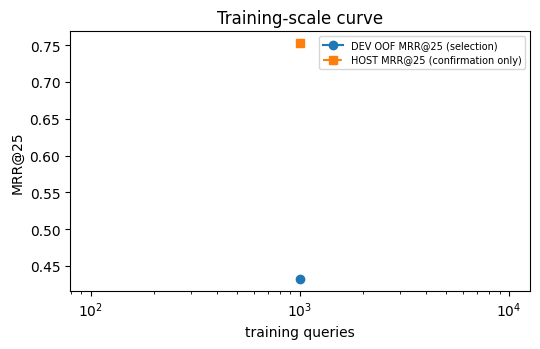

In [17]:
HOST_PQ = {}
for mid in list(BASELINE_FILE) + list(MODELS):
    HOST_PQ[mid] = evaluate_host(LOCK, mid, HOSTP)
    RESULTS['host'][mid] = summarize(HOST_PQ[mid])
    target = D['baselines'] / f'{BASELINE_FILE[mid]}.host_per_query.parquet' if mid in BASELINE_FILE else D['models'] / mid / 'host_per_query.parquet'
    target.parent.mkdir(parents=True, exist_ok=True)   # V1_1k is an alias of V1 and has no model directory of its own
    HOST_PQ[mid].to_parquet(target, index=False)
for bid in BASELINE_FILE:
    save_json({'label': BASELINE_LABELS[bid], 'dev': RESULTS['dev'][bid], 'host': RESULTS['host'][bid],
               'alpha': ALPHAS.get(bid), 'selection_dataset': 'DEV'}, D['baselines'] / f'{BASELINE_FILE[bid]}.summary.json')
host_table = pd.DataFrame([{'model': m, 'dev_oof_mrr': RESULTS['dev'][m]['mrr_at_25'], **{f'host_{k}': v for k, v in RESULTS['host'][m].items()}}
                           for m in HOST_PQ])
display(host_table)
fig = scale_curve(RESULTS['host']); fig.savefig(D['figures'] / 'scale_curve_dev_host.png', dpi=130); plt.show()

## 18. HOST k = 1 / 3 / 5 stress

Historical V0 k=1 ≈ 0.62 (HISTORICAL REFERENCE) is a floor-like diagnostic, because V0 was
trained on reference-rich features. V3-RD is the proper test of whether training for
sparse-reference robustness helps at k = 1.

k,1,3,5
model,,,
B3b,0.476352,0.535902,0.590850
B4,0.581808,0.627217,0.671680
V1,0.674561,0.712000,0.752729
V2,0.674561,0.712000,0.752729
V3,0.685238,0.720519,0.752543
V3_RD,0.666067,0.734233,0.758005
V4,0.664827,0.713674,0.752700


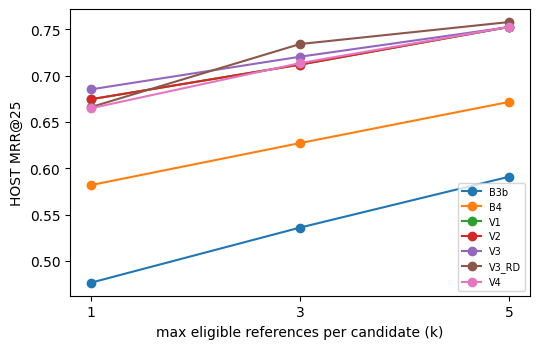

In [18]:
HOST_K = {k: k_features(host_qcr, host_pool, host_meta, k) for k in K_STRESS}
headline_scale = 'V1_10k' if STATUS.get('V1_10k') == 'OK' else ('V1_3k' if STATUS.get('V1_3k') == 'OK' else None)
STRESS_MODELS = list(dict.fromkeys([m for m in ('V1', 'V3', 'V4', 'V3_RD', headline_scale, SELECTED) if m]))
host_stress = pd.DataFrame([{'model': m, 'k': k, **summarize(evaluate_host(LOCK, m, HOST_K[k]))} for m in STRESS_MODELS + ['B3b', 'B4'] for k in K_STRESS])
host_stress.to_parquet(D['stress_tests'] / 'host_k_stress.parquet', index=False)
display(host_stress.pivot(index='model', columns='k', values='mrr_at_25'))
fig, ax = plt.subplots(figsize=(5.5, 3.6))
for m, g in host_stress.groupby('model'):
    ax.plot(g['k'], g['mrr_at_25'], 'o-', label=m)
ax.set_xticks(K_STRESS); ax.set_xlabel('max eligible references per candidate (k)'); ax.set_ylabel('HOST MRR@25'); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(D['figures'] / 'host_k_stress.png', dpi=130); plt.show()

## 19. HOST connectivity-level bootstrap

The HOST set has about 250 connectivities. The CIs resample those, not the spectra.

In [19]:
host_ci = pd.DataFrame([{'model': m, **cluster_bootstrap_mean(pq['rr'].to_numpy(), pq['query_id'].map(CLUSTER_HOST).to_numpy(), n_boot=N_BOOT, seed=SEED)}
                        for m, pq in HOST_PQ.items()])
host_ci.to_parquet(D['bootstrap'] / 'host_mrr_ci.parquet', index=False)
host_boot = major_comparisons(HOST_PQ, CLUSTER_HOST, LOCK.record['best_transparent_baseline_dev'])
host_boot = pd.concat([host_boot, pd.DataFrame([paired_comparison_row(SELECTED, HOST_PQ[SELECTED], 'B2b', HOST_PQ['B2b'], CLUSTER_HOST, n_boot=N_BOOT, seed=SEED)])],
                      ignore_index=True)
host_boot.to_parquet(D['bootstrap'] / 'host_paired_comparisons.parquet', index=False)
display(host_ci[['model', 'mean', 'ci_low', 'ci_high', 'n_queries', 'n_clusters']])
display(host_boot[['comparison', 'mean_a', 'mean_b', 'delta', 'ci_low', 'ci_high', 'excludes_zero', 'n_clusters']])

,model,mean,ci_low,ci_high,n_queries,n_clusters
0,B1,0.399144,0.350191,0.447657,1184,250
1,B1L,0.418290,0.367286,0.467971,1184,250
2,B2a,0.399144,0.350191,0.447657,1184,250
3,B2b,0.483747,0.430635,0.537387,1184,250
4,B3a,0.576702,0.530649,0.617904,1184,250
5,B3b,0.590850,0.545177,0.632154,1184,250
6,B4,0.671680,0.630107,0.711183,1184,250
7,B5,0.758432,0.726074,0.789448,1184,250
8,V1,0.752729,0.718467,0.783890,1184,250
9,V2,0.752729,0.718467,0.783890,1184,250


,comparison,mean_a,mean_b,delta,ci_low,ci_high,excludes_zero,n_clusters
0,V1 vs B4,0.752729,0.671680,0.081049,0.052657,0.110280,True,250
1,V3 vs V1,0.752543,0.752729,-0.000186,-0.010206,0.009542,False,250
2,V4 vs V3,0.752700,0.752543,0.000158,-0.013211,0.013994,False,250
3,V3_RD vs V3,0.758005,0.752543,0.005462,-0.008652,0.019912,False,250
4,V2 vs B2b,0.752729,0.483747,0.268982,0.218750,0.316120,True,250


## 20. Stratification: truth reference richness, candidate-pool size, adduct / instrument / mass

The query count is always shown. Bins with n < 20 are flagged `LOW_N` and should not be
over-interpreted. Truth reference richness uses the **censored** eligible count: `>=5` means
saturated or an exact count of at least 5.

In [20]:
truth_rows = HOSTP[HOSTP['is_true_candidate']].set_index('query_id')
pool_size = HOSTP.groupby('query_id').size()
strata = pd.DataFrame({'query_id': HOST_IDS}).set_index('query_id')
strata['truth_refs_bin'] = pd.cut(truth_rows['eligible_reference_count'].reindex(strata.index), [-0.5, 0.5, 1.5, 4.5, np.inf],
                                  labels=['0', '1', '2-4', '>=5']).astype(object).fillna('truth absent')
strata['pool_size'] = pool_size.reindex(strata.index).fillna(0)
strata['pool_bin'] = pd.qcut(strata['pool_size'].rank(method='first'), 4, labels=['small', 'medium', 'large', 'very large']).astype(str)
hq = host_q.set_index('query_id')
strata['adduct'] = hq['adduct']
strata['instrument_source'] = hq['instrument_type'].astype(str) + ' / ' + hq['source'].astype(str)
strata['mass_bin'] = pd.cut(hq['neutral_mass'], [0, 250, 400, 600, np.inf], labels=['<250', '250-400', '400-600', '>=600']).astype(str)
STRAT_MODELS = list(dict.fromkeys(['V1', 'V3', 'V4', 'V3_RD', SELECTED, LOCK.record['best_transparent_baseline_dev'], 'B2b']))
strat_rows = []
for dim in ('truth_refs_bin', 'pool_bin', 'adduct', 'instrument_source', 'mass_bin'):
    for level, ids in strata.groupby(dim).groups.items():
        for m in STRAT_MODELS:
            pq = HOST_PQ[m].set_index('query_id').loc[list(ids)]
            strat_rows.append({'dimension': dim, 'level': level, 'model': m, 'n_queries': len(ids), 'mrr_at_25': float(pq['rr'].mean()),
                               'hit_at_1': float(pq['hit_at_1'].mean()), 'low_n': len(ids) < LOW_N})
strat = pd.DataFrame(strat_rows)
strat.to_parquet(D['metrics'] / 'host_stratification.parquet', index=False)
for dim in strat['dimension'].unique():
    t = strat[strat['dimension'] == dim].pivot_table(index=['level', 'n_queries'], columns='model', values='mrr_at_25')
    print(f'\n== {dim} (MRR@25; n_queries shown; LOW_N if < {LOW_N})'); display(t)
pool_pq = HOST_PQ[SELECTED].set_index('query_id').join(strata[['pool_bin', 'pool_size']])
pool_summary = pool_pq.groupby('pool_bin').agg(n_queries=('rr', 'size'), mrr=('rr', 'mean'), hit_at_1=('hit_at_1', 'mean'),
                                               median_pool=('pool_size', 'median'))
display(pool_summary)

C:\Users\myben\AppData\Local\Temp\ipykernel_47624\1930953212.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for level, ids in strata.groupby(dim).groups.items():



== truth_refs_bin (MRR@25; n_queries shown; LOW_N if < 20)


,model,B2b,B4,V1,V2,V3,V3_RD,V4
level,n_queries,,,,,,,
2-4,12,0.029676,0.424289,0.52702,0.52702,0.537302,0.385516,0.431349
>=5,1172,0.488396,0.674213,0.75504,0.75504,0.754746,0.761819,0.755991



== pool_bin (MRR@25; n_queries shown; LOW_N if < 20)


,model,B2b,B4,V1,V2,V3,V3_RD,V4
level,n_queries,,,,,,,
large,296,0.394661,0.627246,0.687484,0.687484,0.691961,0.686487,0.712899
medium,296,0.515266,0.724538,0.775453,0.775453,0.759645,0.759180,0.761158
small,296,0.798214,0.822785,0.895758,0.895758,0.893834,0.900820,0.879931
very large,296,0.226846,0.512150,0.652220,0.652220,0.664730,0.685533,0.656814


...


== instrument_source (MRR@25; n_queries shown; LOW_N if < 20)


,model,B2b,B4,V1,V2,V3,V3_RD,V4
level,n_queries,,,,,,,
timsTOF / enveda-np-examples,1184,0.483747,0.67168,0.752729,0.752729,0.752543,0.758005,0.7527



== mass_bin (MRR@25; n_queries shown; LOW_N if < 20)


,model,B2b,B4,V1,V2,V3,V3_RD,V4
level,n_queries,,,,,,,
250-400,509,0.292627,0.569266,0.677519,0.677519,0.684966,0.692076,0.685335
400-600,355,0.581676,0.748539,0.758846,0.758846,0.751082,0.774545,0.755001
<250,161,0.556610,0.725546,0.851655,0.851655,0.843555,0.848997,0.844678
>=600,159,0.803145,0.773386,0.879665,0.879665,0.879979,0.839997,0.870081


,n_queries,mrr,hit_at_1,median_pool
pool_bin,,,,
large,296,0.687484,0.567568,65.0
medium,296,0.775453,0.672297,20.0
small,296,0.895758,0.804054,6.0
very large,296,0.652220,0.530405,261.0


## 21. `near_dup_strict` sensitivity (**SENSITIVITY ANALYSIS**, never used for selection)

In [21]:
sens_rows = []
for m in list(dict.fromkeys(STRESS_MODELS + [LOCK.record['best_transparent_baseline_dev'], 'B2b'])):
    s_mir = RESULTS['host'][m]['mrr_at_25']
    s_nd = summarize(evaluate_host(LOCK, m, host_f[SENS]))['mrr_at_25']
    sens_rows.append({'model': m, 'host_mrr_mirror_aware': s_mir, 'host_mrr_near_dup_strict': s_nd, 'delta_near_dup_minus_mirror': s_nd - s_mir})
sens = pd.DataFrame(sens_rows)
sens.to_parquet(D['metrics'] / 'near_dup_strict_sensitivity.parquet', index=False)
display(sens)

,model,host_mrr_mirror_aware,host_mrr_near_dup_strict,delta_near_dup_minus_mirror
0,V1,0.752729,0.743750,-0.008979
1,V3,0.752543,0.745299,-0.007244
2,V4,0.752700,0.745234,-0.007466
3,V3_RD,0.758005,0.752909,-0.005096
4,V2,0.752729,0.743750,-0.008979
5,B4,0.671680,0.669616,-0.002064
6,B2b,0.483747,0.484193,0.000446


## 22. Near-miss analysis (absorbs the deferred C4/C5 T3-impostor question) + example panels

For every HOST failure of the selected model (truth not at rank 1), the table compares the
rank-1 wrong candidate with the truth. It covers mass, spectral evidence, reference counts,
formula equality, Morgan r=2/2048 Tanimoto (a **diagnostic only**, never a feature) and
whether the wrong candidate's accepted evidence contains a T3 near-duplicate of the query (a
**T3 impostor**).

In [22]:
scored_sel = rank_by_keys(score_frame(MODELS[SELECTED], HOSTP, MODEL_FEATS[SELECTED]),
                          [('score', False), ('abs_mass_error_ppm', True), (KEY, True)])
keys_needed = set(scored_sel.loc[scored_sel['rank'] <= 2, KEY]) | set(HOSTP.loc[HOSTP['is_true_candidate'], KEY])
tm = load_columns(paths.processed / 'train_spectrum_metadata.parquet', ['connectivity_key', 'molecular_formula'])
formula_of_key = tm[tm['connectivity_key'].isin(keys_needed)].drop_duplicates('connectivity_key').set_index('connectivity_key')['molecular_formula'].to_dict()
del tm; gc.collect()
st = pd.read_parquet(paths.interim / 'structure_table.parquet', columns=['connectivity_key', 'canonical_smiles'])
smiles_of_key = st[st['connectivity_key'].isin(keys_needed)].drop_duplicates('connectivity_key').set_index('connectivity_key')['canonical_smiles'].to_dict()
del st
tier_flags = candidate_tier_flags(host_qcr, PRIMARY)
elig_counts = HOSTP[['query_id', KEY, 'eligible_reference_count', 'eligible_reference_saturated']]
nm = build_near_miss_table(scored_sel, HOST_PQ[SELECTED], 'score', formula_of_key, smiles_of_key, tier_flags, elig_counts)
nm.to_parquet(D['near_misses'] / f'host_near_misses_{SELECTED}.parquet', index=False)
nm_summary = near_miss_category_summary(nm, len(HOST_IDS))
nm_summary.to_parquet(D['near_misses'] / 'host_near_miss_categories.parquet', index=False)
display(nm_summary)
prio = nm.sort_values(['cat_t3_impostor', 'cat_high_cosine_decoy', 'cat_same_formula', 'cat_high_tanimoto', 'score_gap'],
                      ascending=[False, False, False, False, True])
display(prio.head(25))

,category,n_failures,share_of_failures,share_of_all_queries
0,high_cosine_decoy,104,0.246445,0.087838
1,t3_impostor,64,0.151659,0.054054
2,same_formula,355,0.841232,0.299831
3,high_tanimoto,60,0.142180,0.050676
4,rank2_near_miss,160,0.379147,0.135135
5,truth_absent,0,0.000000,0.000000


,query_id,pool_size,truth_rank,truth_in_pool,wrong_key,wrong_score,wrong_abs_ppm,wrong_eligible_refs,wrong_has_t3,wrong_n_t3,wrong_cosine_max,wrong_modified_cosine_max,wrong_peak_overlap_frac_max,wrong_neutral_loss_cosine_max,truth_key,truth_score,truth_abs_ppm,truth_eligible_refs,truth_cosine_max,truth_modified_cosine_max,truth_peak_overlap_frac_max,truth_neutral_loss_cosine_max,score_gap,delta_abs_ppm,same_formula,tanimoto_truth_vs_wrong,cat_high_cosine_decoy,cat_t3_impostor,cat_same_formula,cat_high_tanimoto,cat_rank2_near_miss,cat_truth_absent
385,train_2539474,143,2.0,True,QLHTWDQJPOTDMV,1.405564,1.695974,8,True,4,0.998498,0.998298,0.310000,0.998495,XJQPQKLURWNAAH,1.201753,1.695974,5,0.961182,0.935077,0.050000,0.930150,0.203810,0.000000e+00,True,0.760870,True,True,True,True,True,False
64,train_2538622,9,2.0,True,QSFNHAFPXWQTGZ,-0.537398,2.521844,5,True,3,0.983079,0.982841,0.160000,0.983098,DUXQKCCELUKXOE,-0.806867,2.521844,5,0.975701,0.975909,0.050000,0.975705,0.269469,0.000000e+00,True,0.770270,True,True,True,True,True,False
63,train_2538621,9,2.0,True,QSFNHAFPXWQTGZ,0.071174,2.575837,5,True,1,0.973980,0.973291,0.430000,0.972514,DUXQKCCELUKXOE,-0.210629,2.575837,5,0.937601,0.938131,0.030000,0.937648,0.281803,0.000000e+00,True,0.770270,True,True,True,True,True,False
393,train_2539487,12,2.0,True,AEMJDNJKSCBKRL,-0.796745,3.668545,5,True,2,0.965258,0.965810,0.620000,0.966615,XOJVHLIYNSOZOO,-1.080453,3.668545,5,0.781895,0.781111,0.540000,0.783684,0.283708,0.000000e+00,True,1.000000,True,True,True,True,True,False
374,train_2539454,313,2.0,True,WNBCMONIPIJTSB,2.937821,2.317083,5,True,4,0.997668,0.998086,0.166667,0.999241,XHCADAYNFIFUHF,2.488289,2.317083,5,0.998854,0.999206,0.111111,0.999246,0.449532,0.000000e+00,True,0.931818,True,True,True,True,True,False
66,train_2538624,9,2.0,True,QSFNHAFPXWQTGZ,-0.084907,2.619409,5,True,1,0.964341,0.963701,0.380000,0.964341,DUXQKCCELUKXOE,-0.947637,2.619409,5,0.873726,0.873291,0.360000,0.873726,0.862730,0.000000e+00,True,0.770270,True,True,True,True,True,False
375,train_2539455,313,4.0,True,WNBCMONIPIJTSB,0.619296,2.336185,5,True,4,0.987002,0.987162,0.180000,0.988866,XHCADAYNFIFUHF,-0.286490,2.336185,5,0.941601,0.939310,0.220000,0.941705,0.905785,0.000000e+00,True,0.931818,True,True,True,True,False,False
161,train_2538871,42,4.0,True,YFPYXTNSQOUHPS,3.221182,0.654801,5,True,5,0.979864,0.978319,0.625000,0.977813,JYXSWDCPHRTYGU,1.579425,0.654801,5,0.919852,0.917758,0.150000,0.919597,1.641757,0.000000e+00,True,0.791045,True,True,True,True,False,False
343,train_2539345,5,2.0,True,DRSKVOAJKLUMCL,-0.251457,0.231999,5,True,2,0.962527,0.960282,0.312500,0.971713,UEDUENGHJMELGK,-1.985200,0.231999,5,0.519217,0.530147,0.125000,0.582500,1.733743,-1.413351e-10,True,0.794521,True,True,True,True,True,False
142,train_2538831,70,3.0,True,GSTCPEBQYSOEHV,3.465003,0.258832,5,True,2,0.963716,0.965095,0.615385,0.968918,IOUVKUPGCMBWBT,1.658281,0.258832,5,0.980474,0.983774,0.230769,0.986724,1.806722,-1.303339e-10,True,0.807692,True,True,True,True,False,False


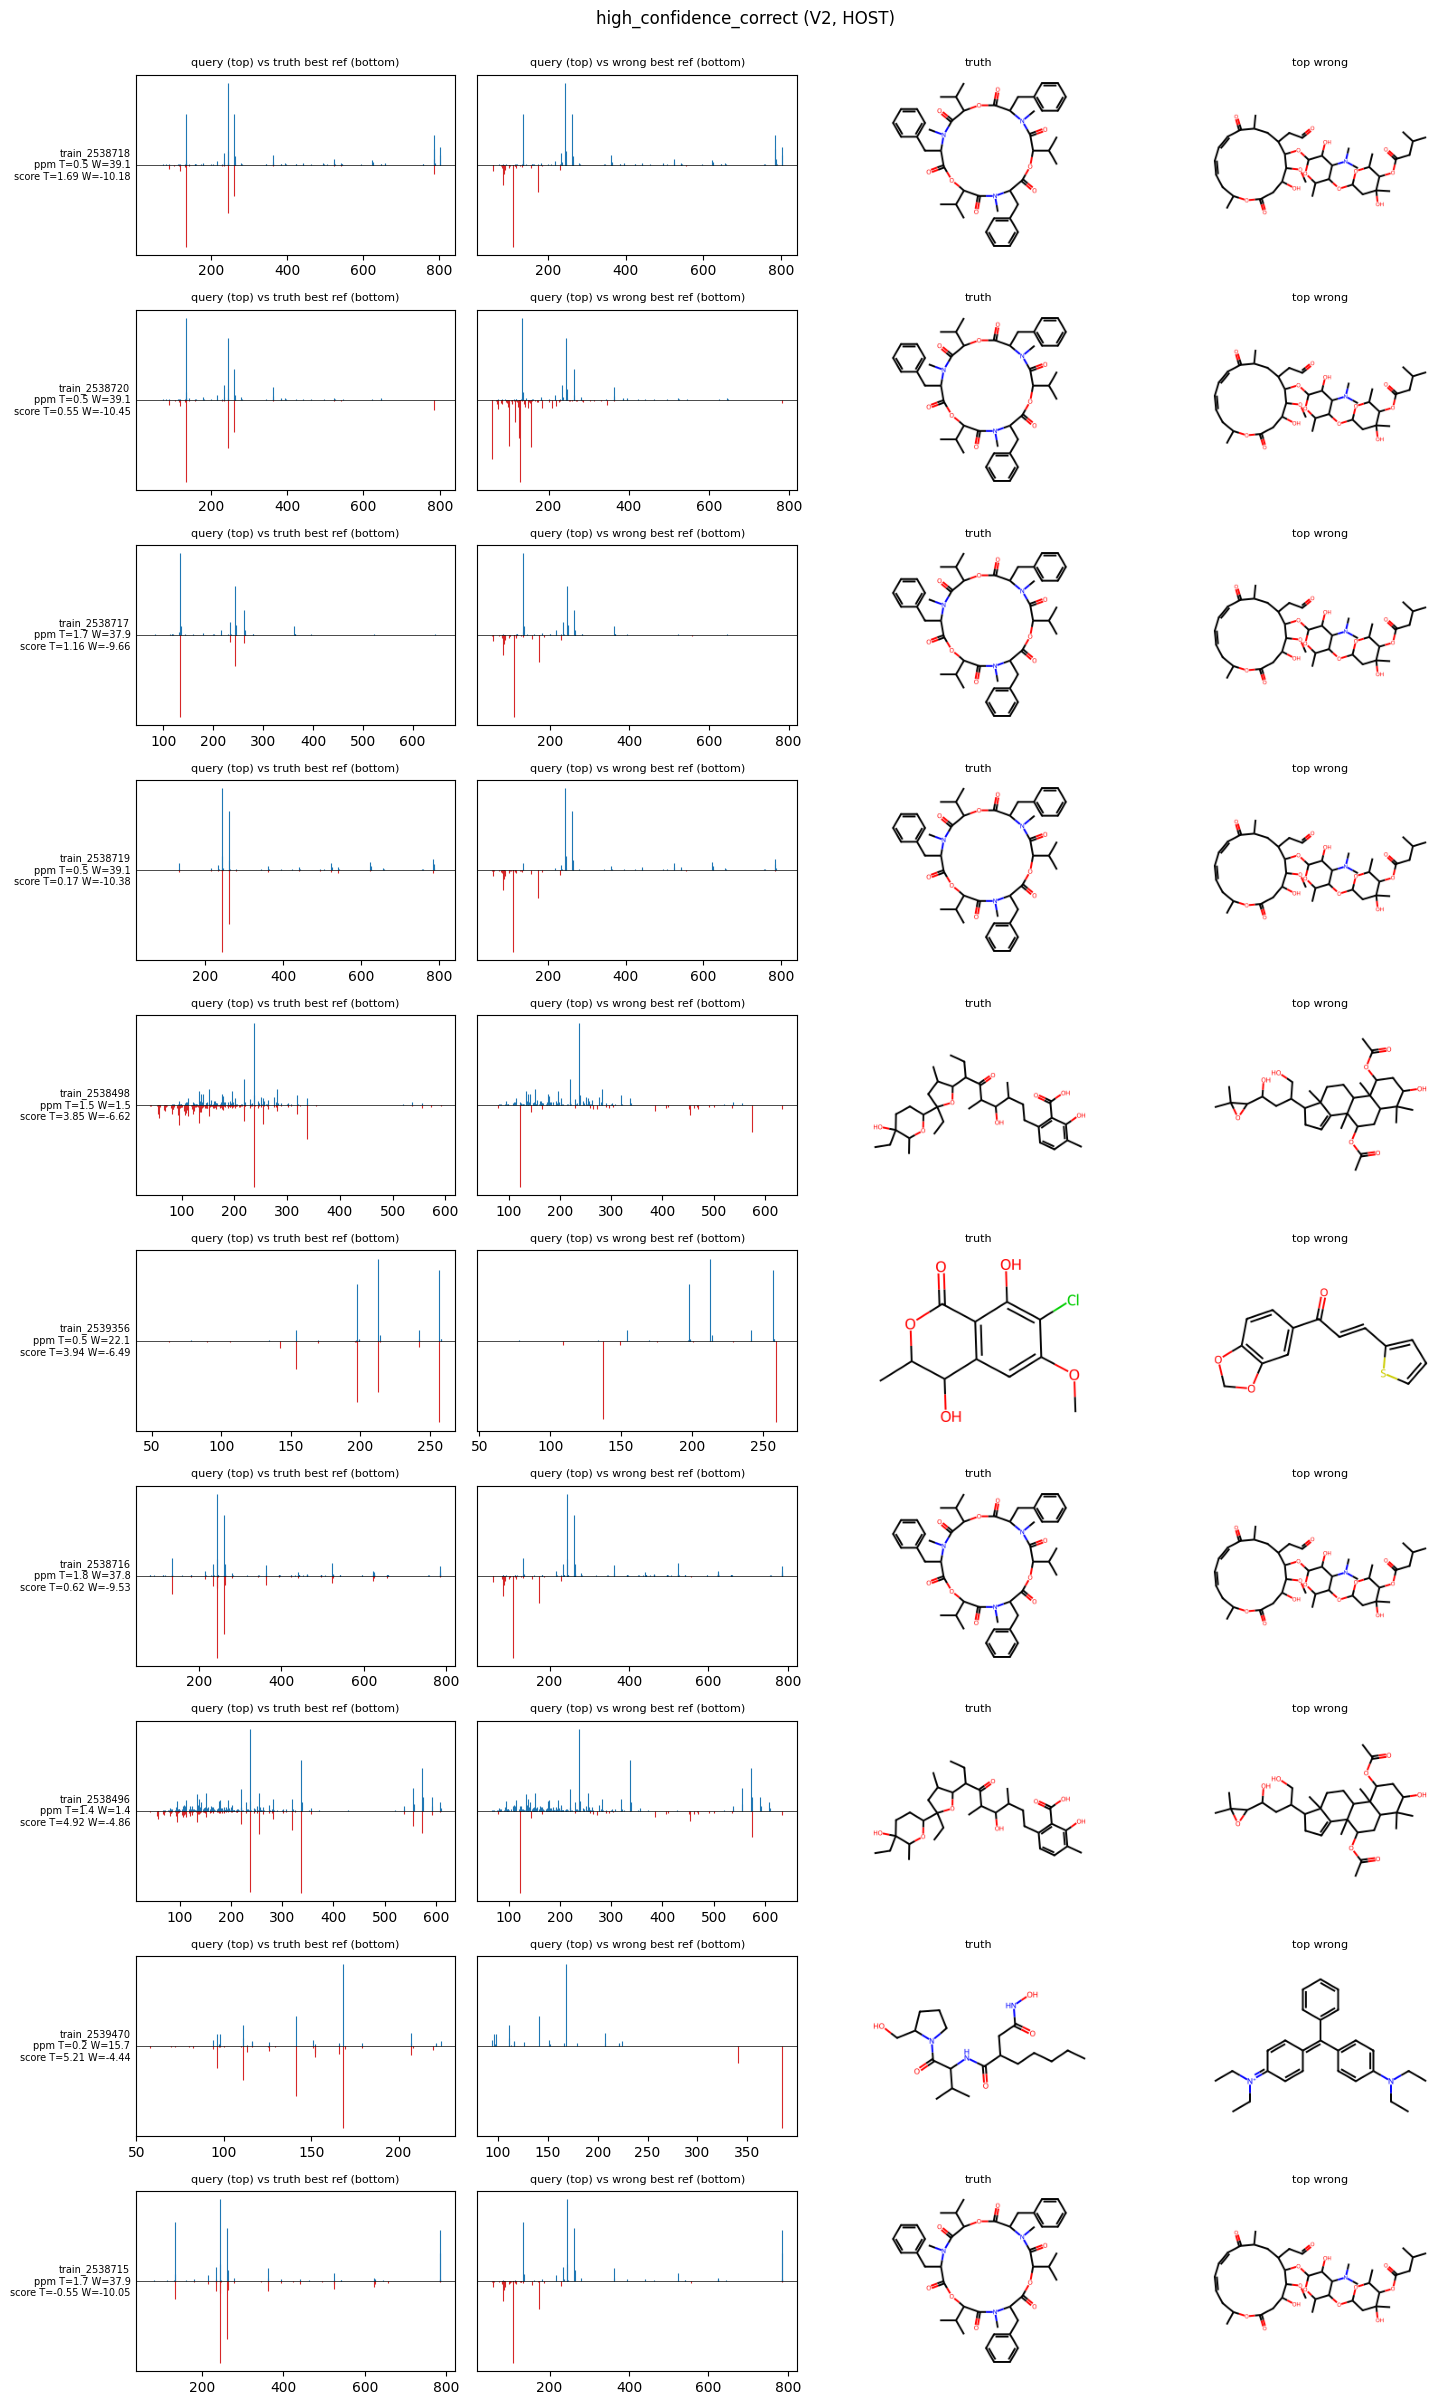

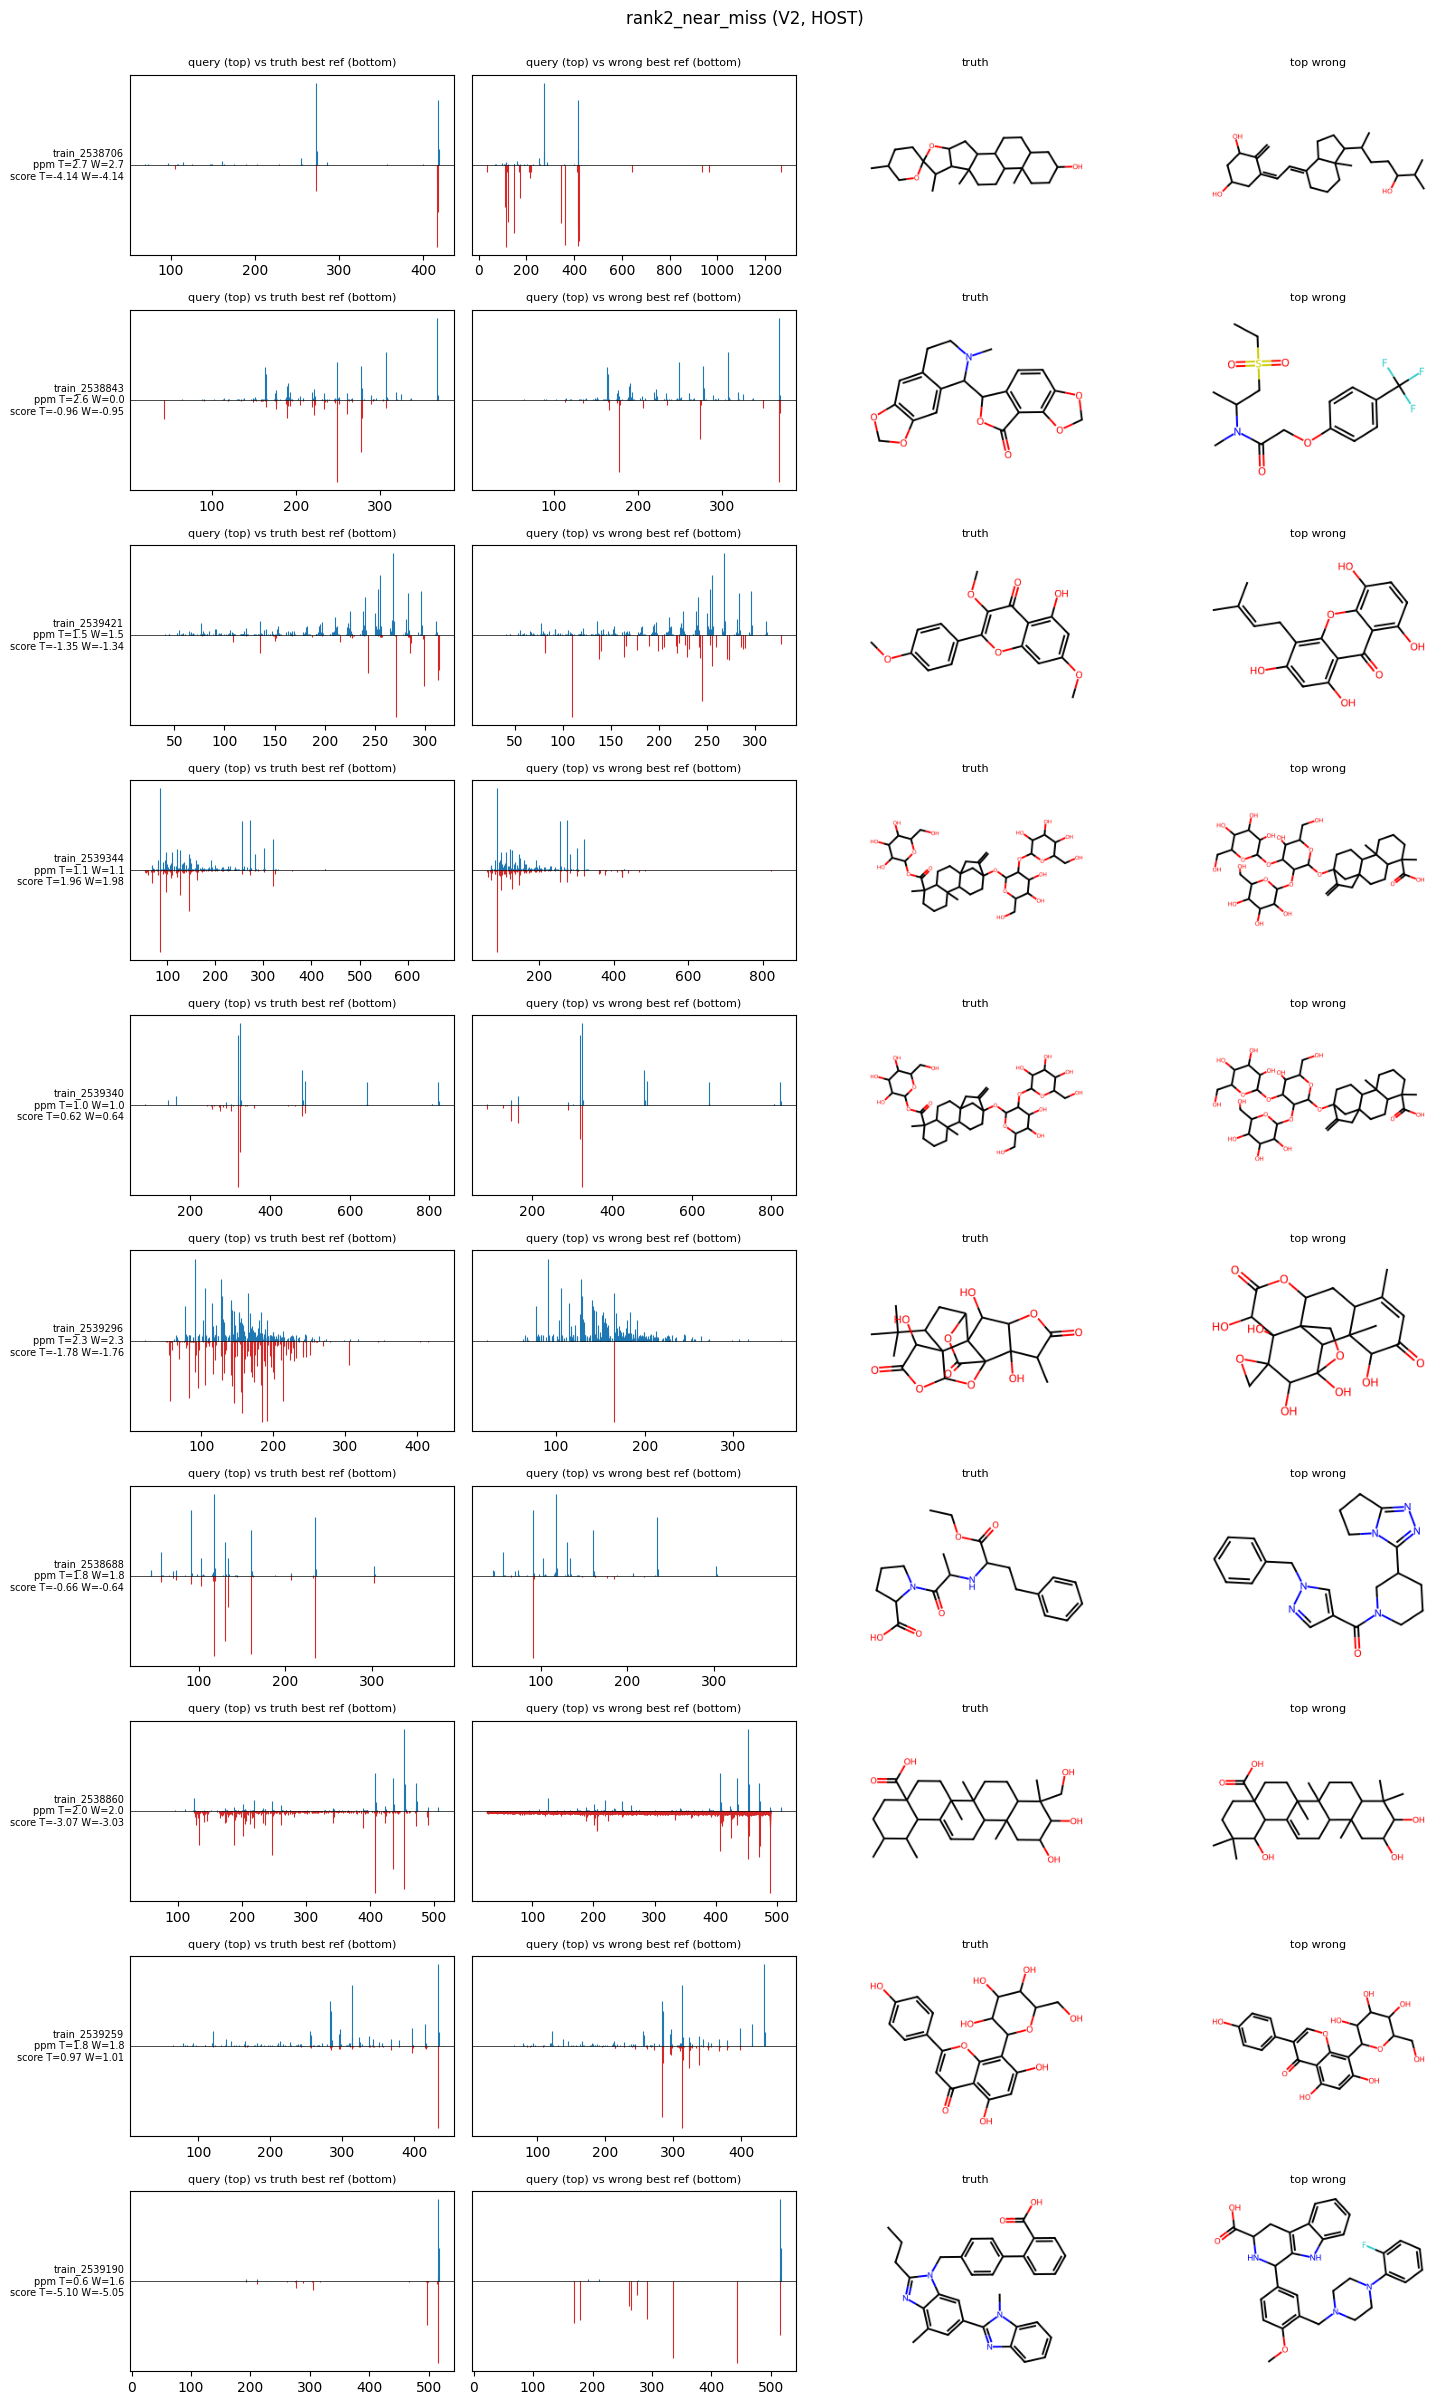

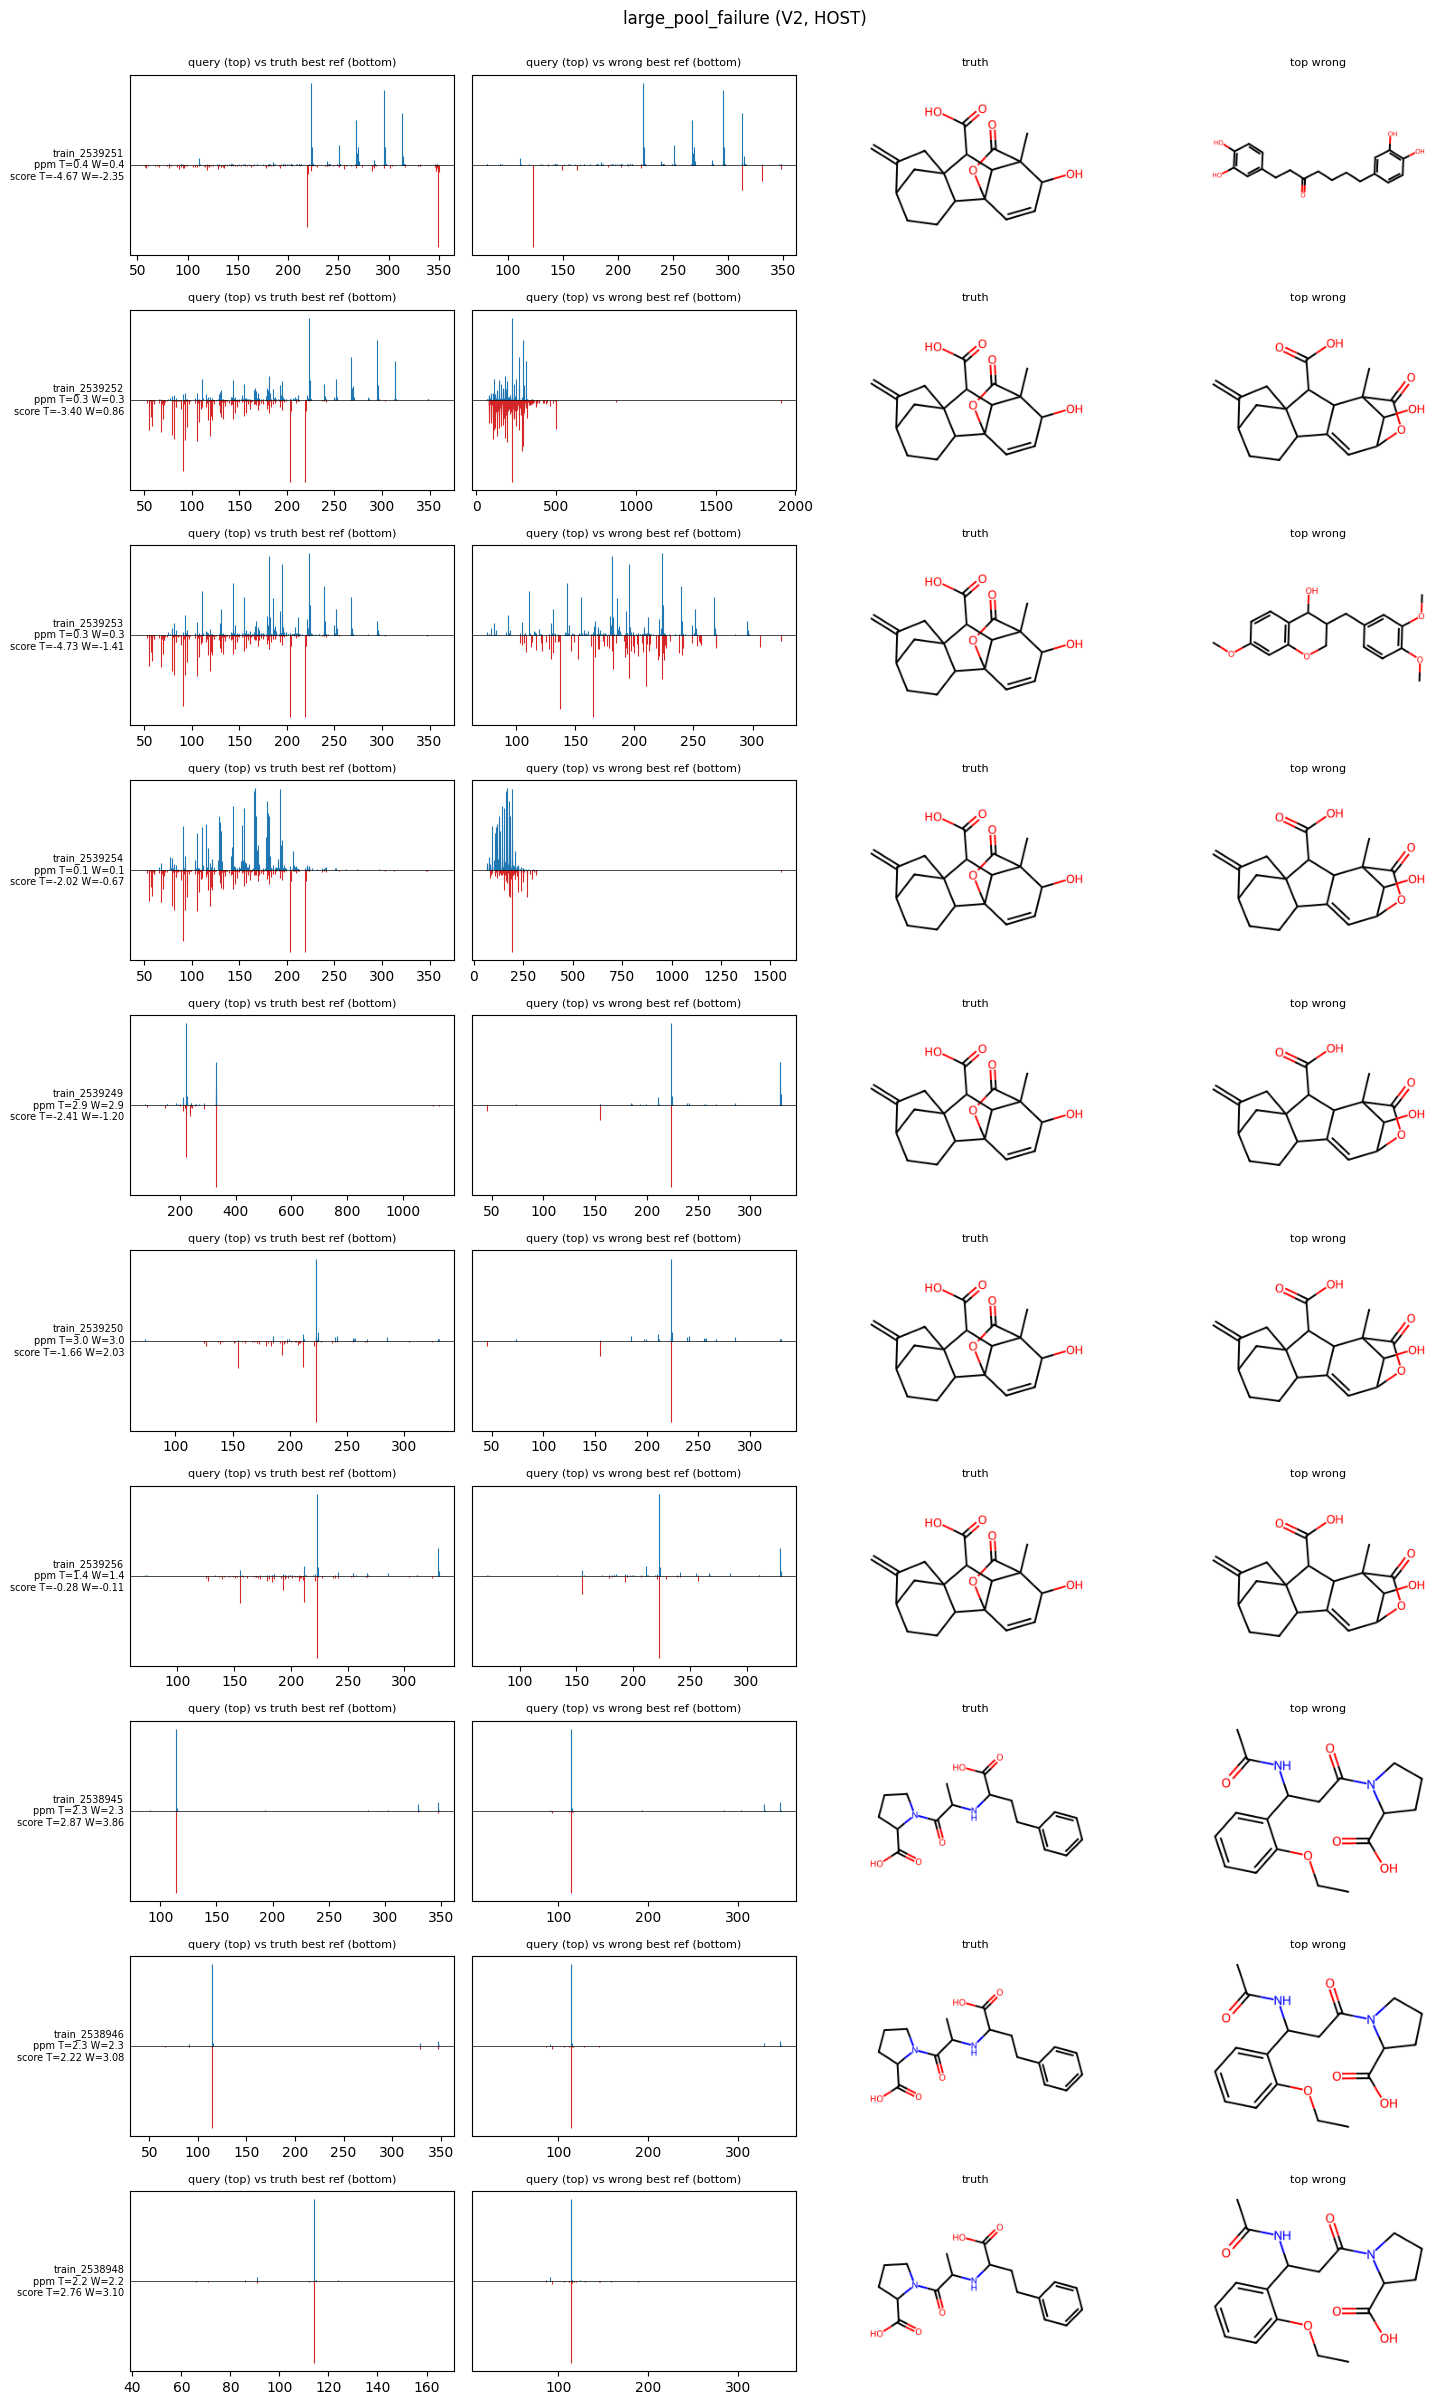

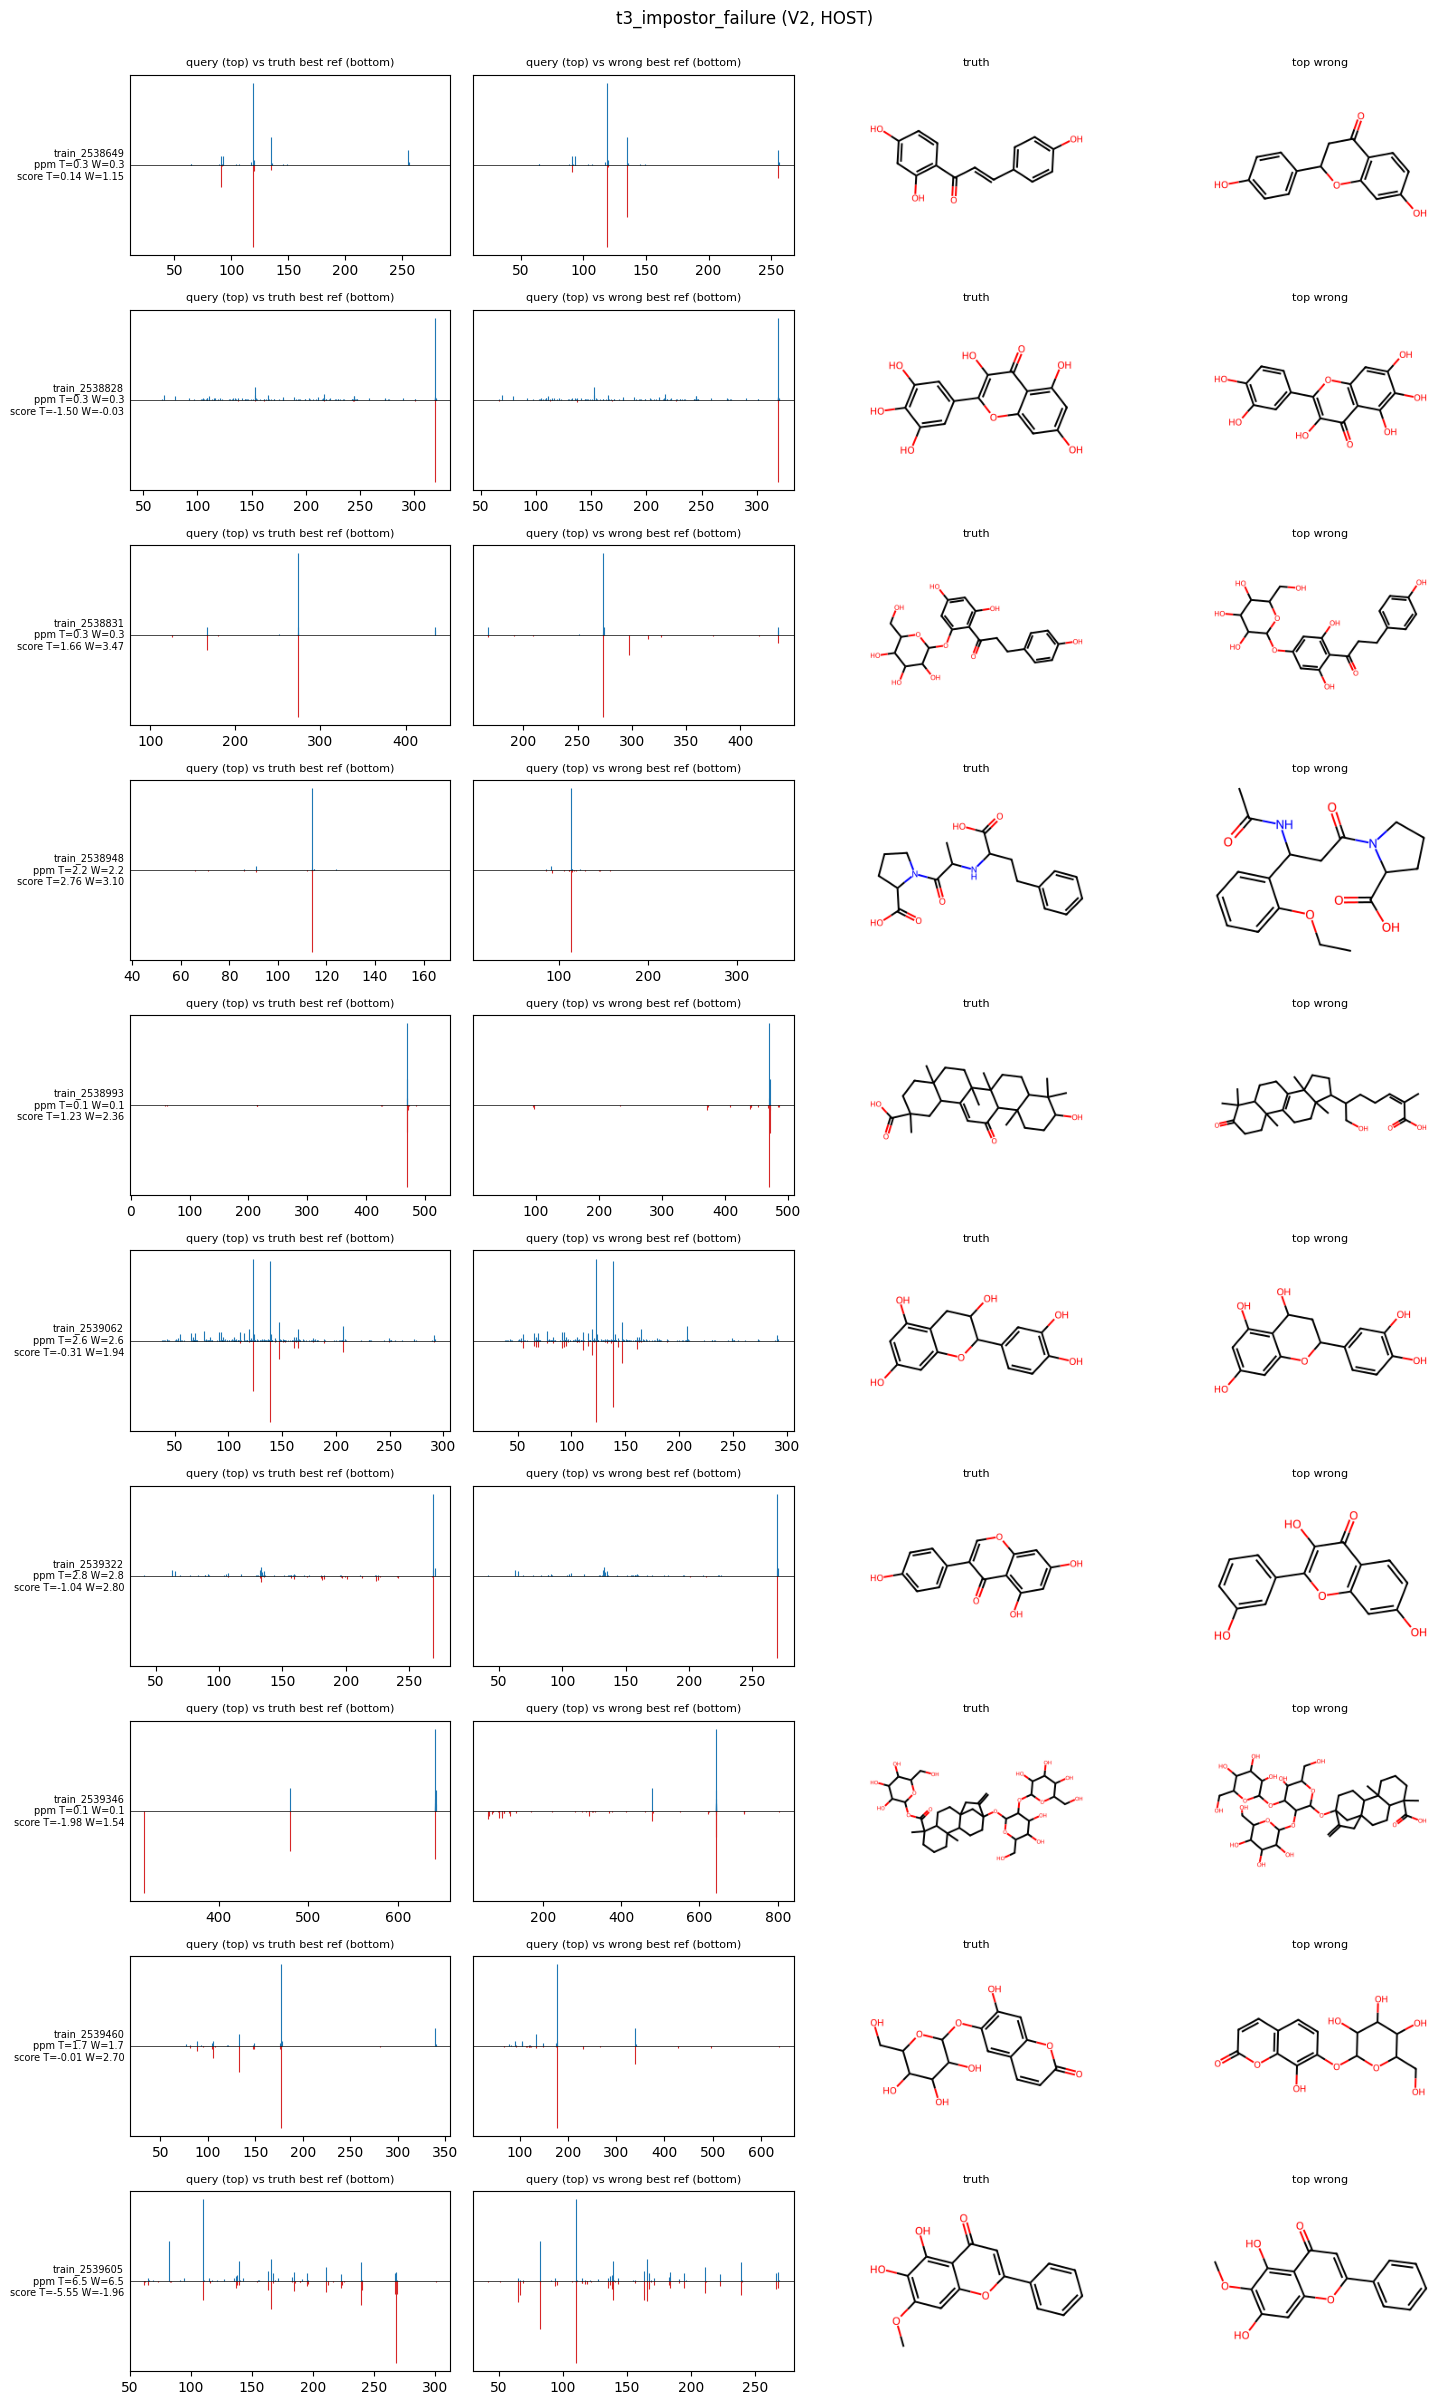

In [23]:
# example panels: 10 high-confidence correct, 10 rank-2 near misses, 10 large-pool failures, 10 T3-impostor failures
examples = select_panel_examples(HOST_PQ[SELECTED], nm, scored_sel, 'score', n=10, seed=SEED)
save_json(examples, D['near_misses'] / 'panel_examples.json')
acc = host_qcr[host_qcr[f'accepted_{PRIMARY}']]
best_ref = acc.sort_values('cosine', ascending=False).drop_duplicates(['query_id', 'candidate_key']).set_index(['query_id', 'candidate_key'])['ref_spectrum_id']
panel_ids = [q for ids in examples.values() for q in ids]
top_wrong = scored_sel[scored_sel['rank'] == 1].set_index('query_id')[KEY]
truth_key = HOSTP[HOSTP['is_true_candidate']].set_index('query_id')[KEY]
second = scored_sel[scored_sel['rank'] == 2].set_index('query_id')[KEY]
offs = set()
for q in panel_ids:
    offs.add(offset_of(q))
    for k in (truth_key.get(q), top_wrong.get(q), second.get(q)):
        rid = best_ref.get((q, k)) if k is not None else None
        if rid is not None:
            offs.add(offset_of(rid))
raw = load_rows_by_offset(paths.train, ['ms2_mzs', 'ms2_normalized_intensities'], sorted(offs)).rename(columns={'_row_offset': 'row_offset'})
peaks = {int(r.row_offset): {'mzs': np.asarray(r.ms2_mzs), 'intensities': np.asarray(r.ms2_normalized_intensities)} for r in raw.itertuples(index=False)}
del raw
score_of = scored_sel.set_index(['query_id', KEY])['score']
ppm_of = HOSTP.set_index(['query_id', KEY])['abs_mass_error_ppm']
for family, ids in examples.items():
    if not ids:
        print(f'{family}: no examples'); continue
    fig, axes = plt.subplots(len(ids), 4, figsize=(15, 2.4 * len(ids)), squeeze=False)
    for i, q in enumerate(ids):
        tk = truth_key.get(q)
        wk = top_wrong.get(q) if top_wrong.get(q) != tk else second.get(q)   # for correct queries show the runner-up
        tr = best_ref.get((q, tk)) if tk is not None else None
        wr = best_ref.get((q, wk)) if wk is not None else None
        title = (f'{q}\nppm T={ppm_of.get((q, tk), np.nan):.1f} W={ppm_of.get((q, wk), np.nan):.1f}\n'
                 f'score T={score_of.get((q, tk), np.nan):.2f} W={score_of.get((q, wk), np.nan):.2f}')
        plot_example_panel(axes[i], peaks.get(offset_of(q)), peaks.get(offset_of(tr)) if tr else None, peaks.get(offset_of(wr)) if wr else None,
                           smiles_of_key.get(tk), smiles_of_key.get(wk), title)
    fig.suptitle(f'{family} ({SELECTED}, HOST)', y=1.0); fig.tight_layout()
    fig.savefig(D['figures'] / f'panel_{family}.png', dpi=110); plt.show()

## 23. Final freeze table

In [24]:
host_k = host_stress.pivot(index='model', columns='k', values='mrr_at_25')
ci_of = host_ci.set_index('model')
nd_of = sens.set_index('model')['delta_near_dup_minus_mirror']
b2b_host = RESULTS['host']['B2b']['mrr_at_25']
rows = []
for m in HOST_PQ:
    sm = strat[(strat['model'] == m)]
    pool_s = sm[sm['dimension'] == 'pool_bin'].set_index('level')['mrr_at_25']
    ref_s = sm[sm['dimension'] == 'truth_refs_bin'].set_index('level')
    rows.append({
        'model': m, 'label': BASELINE_LABELS.get(m, m), 'selection_dataset': 'DEV',
        'is_dev_selected_headline': m == SELECTED, 'dev_oof_mrr': RESULTS['dev'][m]['mrr_at_25'],
        'host_mrr': RESULTS['host'][m]['mrr_at_25'], 'host_hit_at_1': RESULTS['host'][m]['hit_at_1'],
        'host_hit_at_5': RESULTS['host'][m]['hit_at_5'], 'host_hit_at_25': RESULTS['host'][m]['hit_at_25'],
        'k1_mrr': host_k.loc[m, 1] if m in host_k.index else np.nan, 'k3_mrr': host_k.loc[m, 3] if m in host_k.index else np.nan,
        'k5_mrr': host_k.loc[m, 5] if m in host_k.index else np.nan,
        'host_ci_low': ci_of.loc[m, 'ci_low'], 'host_ci_high': ci_of.loc[m, 'ci_high'],
        'pool_robustness_verylarge_minus_small': (pool_s.get('very large', np.nan) - pool_s.get('small', np.nan)) if len(pool_s) else np.nan,
        'refrich_ge5_mrr': ref_s['mrr_at_25'].get('>=5', np.nan) if len(ref_s) else np.nan,
        'refrich_2to4_mrr': ref_s['mrr_at_25'].get('2-4', np.nan) if len(ref_s) else np.nan,
        'refrich_2to4_n': ref_s['n_queries'].get('2-4', 0) if len(ref_s) else 0,
        'b2b_gap': RESULTS['host'][m]['mrr_at_25'] - b2b_host,
        'near_dup_strict_delta': nd_of.get(m, np.nan),
    })
freeze_table = pd.DataFrame(rows).sort_values(['is_dev_selected_headline', 'dev_oof_mrr'], ascending=[False, False])
freeze_table.to_parquet(D['metrics'] / 'freeze_table.parquet', index=False)
freeze_table.to_csv(D['metrics'] / 'freeze_table.csv', index=False)
display(freeze_table)
print(f"\nB2b POPULARITY GAP: headline {SELECTED} HOST MRR {RESULTS['host'][SELECTED]['mrr_at_25']:.4f} - B2b {b2b_host:.4f} = "
      f"{RESULTS['host'][SELECTED]['mrr_at_25'] - b2b_host:+.4f}")

,model,label,selection_dataset,is_dev_selected_headline,dev_oof_mrr,host_mrr,host_hit_at_1,host_hit_at_5,host_hit_at_25,k1_mrr,k3_mrr,k5_mrr,host_ci_low,host_ci_high,pool_robustness_verylarge_minus_small,refrich_ge5_mrr,refrich_2to4_mrr,refrich_2to4_n,b2b_gap,near_dup_strict_delta
9,V2,V2,DEV,True,0.431799,0.752729,0.643581,0.891047,0.982264,0.674561,0.712000,0.752729,0.718467,0.783890,-0.243538,0.755040,0.527020,12,0.268982,-0.008979
11,V4,V4,DEV,False,0.434906,0.752700,0.645270,0.900338,0.978885,0.664827,0.713674,0.752700,0.718638,0.785146,-0.223117,0.755991,0.431349,12,0.268954,-0.007466
10,V3,V3,DEV,False,0.432402,0.752543,0.642736,0.892736,0.984797,0.685238,0.720519,0.752543,0.718466,0.784742,-0.229104,0.754746,0.537302,12,0.268796,-0.007244
8,V1,V1,DEV,False,0.431799,0.752729,0.643581,0.891047,0.982264,0.674561,0.712000,0.752729,0.718467,0.783890,-0.243538,0.755040,0.527020,12,0.268982,-0.008979
13,V1_1k,V1_1k,DEV,False,0.431799,0.752729,0.643581,0.891047,0.982264,NaN,NaN,NaN,0.718467,0.783890,NaN,NaN,NaN,0,0.268982,NaN
12,V3_RD,V3_RD,DEV,False,0.429251,0.758005,0.645270,0.897804,0.985642,0.666067,0.734233,0.758005,0.724592,0.789258,-0.215288,0.761819,0.385516,12,0.274258,-0.005096
6,B4,B4 peak overlap + alpha*mass likelihood,DEV,False,0.358405,0.671680,0.543074,0.839527,0.953547,0.581808,0.627217,0.671680,0.630107,0.711183,-0.310636,0.674213,0.424289,12,0.187933,-0.002064
7,B5,B5 modified cosine + alpha*mass likelihood,DEV,False,0.352796,0.758432,0.658784,0.891047,0.970439,NaN,NaN,NaN,0.726074,0.789448,NaN,NaN,NaN,0,0.274685,NaN
1,B1L,B1L mass likelihood,DEV,False,0.292846,0.418290,0.235642,0.647804,0.919764,NaN,NaN,NaN,0.367286,0.467971,NaN,NaN,NaN,0,-0.065457,NaN
0,B1,B1 mass only,DEV,False,0.289946,0.399144,0.214527,0.647804,0.915541,NaN,NaN,NaN,0.350191,0.447657,NaN,NaN,NaN,0,-0.084603,NaN



B2b POPULARITY GAP: headline V2 HOST MRR 0.7527 - B2b 0.4837 = +0.2690


## 24. Mode-A freeze decision

The headline model is the DEV-selected one. It is never swapped on HOST evidence. A HOST
drop larger than the pre-registered margin produces a **domain-shift warning**, not a
different model.

In [25]:
dev_sel, host_sel = RESULTS['dev'][SELECTED]['mrr_at_25'], RESULTS['host'][SELECTED]['mrr_at_25']
domain_shift_warning = bool(host_sel < dev_sel - PREREGISTERED_RULE['domain_shift_margin'])
evidence = {
    'cache_decision': settlement['decision'], 'selected_model_id': SELECTED,
    'host_metrics_exist': SELECTED in RESULTS['host'], 'bootstrap_exists': len(host_ci) > 0 and len(host_boot) > 0,
    'k_stress_exists': set(K_STRESS) <= set(host_stress.loc[host_stress['model'] == SELECTED, 'k']),
    'b2b_exists': 'B2b' in RESULTS['host'], 'near_miss_exists': (D['near_misses'] / f'host_near_misses_{SELECTED}.parquet').exists(),
    'top3_contract_holds': RESULTS.get('top3_contract_holds', False),
}
freeze_status, conditions = mode_a_freeze_conditions(evidence)
summary = {
    'status': freeze_status, 'conditions': conditions, 'selected_model_id': SELECTED, 'selection_rule_sha256': prereg['rule_sha256'],
    'dev_oof_mrr_selected': dev_sel, 'host_mrr_selected': host_sel,
    'host_ci_selected': host_ci.set_index('model').loc[SELECTED, ['ci_low', 'ci_high']].to_dict(),
    'b2b_popularity_host_mrr': b2b_host, 'b2b_gap': host_sel - b2b_host,
    'domain_shift_warning': domain_shift_warning, 'domain_shift_margin': PREREGISTERED_RULE['domain_shift_margin'],
    'model_status': STATUS, 'alphas': ALPHAS, 'cache_settlement': {k: settlement.get(k) for k in ('decision', 'evidence_fingerprint')},
    'query_accounting': RESULTS['query_accounting'], 'dev': RESULTS['dev'], 'host': RESULTS['host'],
    'waivers': ['W1', 'W2', 'W3'], 'runtime_seconds': time.time() - NOTEBOOK_START,
    'notebook_11': 'NOT STARTED -- next stage decided after review of these results',
}
save_json(summary, OUT / 'modeA_freeze_summary.json')
register_baseline('host_mode_a_v4b', {'name': 'host_mode_a_v4b', 'status': freeze_status, 'selected_model_id': SELECTED,
                                      'dev_oof_mrr': dev_sel, 'host_mrr': host_sel, 'domain_shift_warning': domain_shift_warning,
                                      'use_for_model_selection': False, 'use_for_confirmation': True},
                  paths.processed / 'baseline_registry.json', source_notebook='10v4b_01_modeA_ranking_freeze.ipynb', overwrite=True)
log_decision(decision=f'v4b Mode-A freeze status: {freeze_status} (headline {SELECTED}, DEV-selected)',
             evidence_used='modeA_freeze_summary.json; HOST used for confirmation only', host_visible=True,
             category='pre_registered_choice', log_path=DECISION_LOG_PATH)
print('=' * 72)
print('MODE-A FREEZE STATUS:', freeze_status)
for k, v in conditions.items():
    print(f'   {"OK " if v else "NO "} {k}')
print(f'DEV-selected headline: {SELECTED} | DEV OOF MRR@25 {dev_sel:.4f} | HOST MRR@25 {host_sel:.4f}')
if domain_shift_warning:
    print(f"DOMAIN-SHIFT WARNING: HOST is more than {PREREGISTERED_RULE['domain_shift_margin']} below DEV OOF -- reported, model NOT swapped")
print('NOTEBOOK 11: not started')
print(f'runtime {summary["runtime_seconds"] / 60:.1f} min')
print('=' * 72)

MODE-A FREEZE STATUS: FROZEN
   OK  cache_settled
   OK  dev_selected_headline_model_exists
   OK  host_confirmation_metrics_exist
   OK  connectivity_bootstrap_exists
   OK  k_stress_1_3_5_exists
   OK  b2b_popularity_baseline_exists
   OK  near_miss_analysis_exists
   OK  no_unresolved_missingness_shortcut
DEV-selected headline: V2 | DEV OOF MRR@25 0.4318 | HOST MRR@25 0.7527
NOTEBOOK 11: not started
runtime 45.7 min
